# Delta-Gamma Variance Enhanced Options Model (Zhao & Palomar 2018)

This notebook implements the **delta-gamma variance enhanced** strategy from:

> *"A Markowitz Portfolio Approach to Options Trading"* — Licheng Zhao & Daniel P. Palomar, IEEE Trans. Signal Processing, 2018.

We model option expected returns and variance using first- and second-order Taylor expansion (delta-gamma approximation) under **lognormal GBM** assumptions. Greeks are computed from Black-Scholes using SPY chain data (IV from market or BS inversion).

**Goals:**
1. Implement the model exactly as in the paper with explicit assumptions
2. Unit tests for the model
3. §6-style robustness test: predicted vs realized (compare to `distribution.ipynb` GMM model)

---
## 1. Setup and imports

In [1]:
%matplotlib inline
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import norm
from scipy.optimize import brentq

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from config import SPY_DAILY_FILE, OPTION_CHAINS_DIR
from data.forecasts import (
    _bs_call_price, _bs_put_price,
    _bs_delta, _bs_gamma, _bs_theta,
    _bs_implied_vol,
    load_chain_for_expiry,
)

print("Imports OK")

Imports OK


---
## 2. Paper assumptions (explicitly stated)

**Assumption 1 (GBM):** The stock price $S_t$ satisfies geometric Brownian motion:
$$dS_t = \mu S_t \, dt + \sigma S_t \, dz_t$$
where $\mu$ = drift (expected return), $\sigma$ = volatility, $z_t$ = Wiener process.

**Assumption 2:** Derivative price $F_t = F_t(S_t, t)$ depends only on underlying and time.

**Assumption 3 (discrete time):** For short $\Delta t$:
- Underlying: $\Delta S_t \approx \mu S_t \Delta t + \sigma S_t \Delta z_t$
- Derivative (Itô): $\Delta F_t \approx \left(\frac{\partial F}{\partial S}\mu S + \frac{\partial F}{\partial t} + \frac{1}{2}\frac{\partial^2 F}{\partial S^2}\sigma^2 S^2\right)\Delta t + \frac{\partial F}{\partial S}\sigma S \Delta z_t$

**Assumption 4:** $\mu$ and $\sigma$ stay constant over short $\Delta t$; estimated from historical prices.

**Assumption 5:** Higher-order Greeks (beyond $\Delta$, $\Theta$, $\Gamma$) are ignored.

**Assumption 6:** Options priced via Black-Scholes (European); Greeks from BS formulas. American options approximated by European.

---
## 3. Delta-gamma model: expected returns and variance

In [2]:
def normalize_theta(theta_raw: float, *, theta_is_per_year: bool = True) -> float:
    """Convert theta to a one-trading-day dollar decay."""
    if theta_raw is None or np.isnan(theta_raw):
        return np.nan
    return theta_raw / 252.0 if theta_is_per_year else theta_raw


def delta_gamma_expected_return(
    mu: float,
    sigma: float,
    S: float,
    delta: float,
    theta: float,
    gamma: float,
    price: float,
    dt: float = 1.0 / 252.0,
) -> float:
    """
    Expected option return over dt (paper eq. 8-9).
    E[dC/C] = (1/C) * (Delta*mu*S + Theta + 0.5*Gamma*sigma^2*S^2) * dt
    """
    if price <= 0:
        return 0.0
    drift = delta * mu * S + theta + 0.5 * gamma * (sigma ** 2) * (S ** 2)
    return (drift / price) * dt


def delta_gamma_exposure(delta: float, S: float, price: float) -> float:
    """
    Exposure to underlying: v_i = Delta*S / price (paper eq. 19, vi vector).
    Stock has exposure 1; option has exposure Delta*S/C.
    """
    if price <= 0:
        return 0.0
    return delta * S / price


def build_delta_gamma_moments(
    spot: float,
    mu: float,
    sigma: float,
    r: float,
    T: float,
    K_call: float,
    K_put: float,
    C0: float,
    P0: float,
    dt: float = 1.0 / 252.0,
    sigma_greeks: float | None = None,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Build mu (expected returns) and Sigma (covariance) for [underlying, call, put, cash].
    Uses paper formulas with GBM and delta-gamma approximation.
    sigma: underlying process vol (for variance and drift 0.5*Gamma*sigma^2*S^2).
    sigma_greeks: vol for BS Greeks (default=sigma; use IV for market-implied).
    """
    sig_g = sigma_greeks if sigma_greeks is not None else sigma
    delta_c = _bs_delta(spot, K_call, r, T, sig_g, is_call=True)
    delta_p = _bs_delta(spot, K_put, r, T, sig_g, is_call=False)
    gamma_c = _bs_gamma(spot, K_call, r, T, sig_g)
    gamma_p = _bs_gamma(spot, K_put, r, T, sig_g)
    theta_c = _bs_theta(spot, K_call, r, T, sig_g, is_call=True)
    theta_p = _bs_theta(spot, K_put, r, T, sig_g, is_call=False)

    mu_und = mu * dt
    mu_call = delta_gamma_expected_return(mu, sigma, spot, delta_c, theta_c, gamma_c, C0, dt)
    mu_put = delta_gamma_expected_return(mu, sigma, spot, delta_p, theta_p, gamma_p, P0, dt)
    mu_cash = np.exp(r * dt) - 1.0

    mu_vec = np.array([mu_und, mu_call, mu_put, mu_cash])

    v = np.array([
        1.0,
        delta_gamma_exposure(delta_c, spot, C0),
        delta_gamma_exposure(delta_p, spot, P0),
        0.0,
    ])
    sigma2_und = (sigma ** 2) * dt
    Sigma = np.outer(v, v) * sigma2_und
    Sigma[3, :] = 0.0
    Sigma[:, 3] = 0.0
    Sigma[3, 3] = 1e-12

    return mu_vec, Sigma


---
## 4. Load chain and compute Greeks

In [3]:
def load_chain_atm(chain_date: str, spot: float, underlying: str = "SPY") -> dict:
    """Load calls/puts, pick the nearest-expiry ATM pair, and compute IV."""

    def _load_raw_chain(date_str: str) -> tuple[pd.DataFrame, pd.DataFrame, str]:
        chain_dir = OPTION_CHAINS_DIR if underlying == "SPY" else OPTION_CHAINS_DIR / underlying
        calls = pd.read_parquet(chain_dir / f"calls_{date_str}.parquet")
        puts = pd.read_parquet(chain_dir / f"puts_{date_str}.parquet")
        cleaned = []
        for raw in (calls, puts):
            df = raw.copy()
            rename_map = {}
            if "impliedVolatility" in df.columns and "impl_vol" not in df.columns:
                rename_map["impliedVolatility"] = "impl_vol"
            if "lastPrice" in df.columns and "lastprice" not in df.columns:
                rename_map["lastPrice"] = "lastprice"
            if rename_map:
                df = df.rename(columns=rename_map)
            for col in ("strike", "bid", "ask", "lastprice", "impl_vol"):
                if col in df.columns:
                    df[col] = pd.to_numeric(df[col], errors="coerce")
            if "expiry" not in df.columns:
                raise ValueError("Option chain missing 'expiry' column")
            df["expiry"] = pd.to_datetime(df["expiry"]).dt.normalize()
            bid = df.get("bid", pd.Series(np.nan, index=df.index))
            ask = df.get("ask", pd.Series(np.nan, index=df.index))
            last = df.get("lastprice", pd.Series(np.nan, index=df.index))
            has_quote = (bid > 0) & (ask > 0) & (ask >= bid)
            mid = 0.5 * (bid + ask)
            df["mid"] = mid.where(has_quote, last)
            cleaned.append(df[df["mid"] > 0].copy())
        calls, puts = cleaned
        common_expiries = sorted(set(calls["expiry"].dropna()) & set(puts["expiry"].dropna()))
        if not common_expiries:
            raise ValueError(f"No common expiries in chain for {date_str}")
        ref_ts = pd.Timestamp(chain_date)
        future_expiries = [exp for exp in common_expiries if exp > ref_ts]
        expiry_used = future_expiries[0] if future_expiries else common_expiries[-1]
        calls = calls[calls["expiry"] == expiry_used].copy()
        puts = puts[puts["expiry"] == expiry_used].copy()
        return calls, puts, str(expiry_used.date())

    try:
        calls, puts, expiry_used = load_chain_for_expiry(
            chain_date=chain_date, underlying=underlying, min_mid=0.05
        )
    except ValueError:
        calls, puts, expiry_used = _load_raw_chain(chain_date)

    if len(calls) == 0 or len(puts) == 0:
        raise ValueError(f"No options for {chain_date}")

    atm_call = calls.loc[(calls["strike"] - spot).abs().idxmin()]
    atm_put = puts.loc[(puts["strike"] - spot).abs().idxmin()]

    K_call = float(atm_call["strike"])
    K_put = float(atm_put["strike"])
    C0 = max(float(atm_call["mid"]), 0.10)
    P0 = max(float(atm_put["mid"]), 0.10)

    T = max((pd.Timestamp(expiry_used) - pd.Timestamp(chain_date)).days / 365.0, 1e-6)
    r = 0.05

    iv_c = atm_call.get("impl_vol", np.nan)
    if not np.isfinite(iv_c) or iv_c <= 0:
        iv_c = _bs_implied_vol(C0, spot, K_call, r, T, is_call=True) or 0.15
    iv_p = atm_put.get("impl_vol", np.nan)
    if not np.isfinite(iv_p) or iv_p <= 0:
        iv_p = _bs_implied_vol(P0, spot, K_put, r, T, is_call=False) or 0.15
    iv = float(np.mean([iv_c, iv_p]))

    return {
        "K_call": K_call,
        "K_put": K_put,
        "C0": C0,
        "P0": P0,
        "iv": iv,
        "expiry": expiry_used,
        "calls": calls,
        "puts": puts,
    }


---
## 5. Unit tests

In [4]:
def test_bs_greeks_consistency():
    """BS call/put price change is well-approximated by delta, gamma, and theta."""
    S, K, r, T, sigma = 100.0, 100.0, 0.05, 30 / 365.0, 0.20
    dS, dt = 1.0, 1 / 252.0
    delta_c = _bs_delta(S, K, r, T, sigma, is_call=True)
    gamma_c = _bs_gamma(S, K, r, T, sigma)
    theta_c = _bs_theta(S, K, r, T, sigma, is_call=True)
    C0 = _bs_call_price(S, K, r, T, sigma)
    C1 = _bs_call_price(S + dS, K, r, T - dt, sigma)
    dC_exact = C1 - C0
    dC_approx = delta_c * dS + 0.5 * gamma_c * (dS ** 2) + theta_c * dt
    err = abs(dC_exact - dC_approx)
    assert err < 0.5, f"Delta-gamma approx error {err} too large"
    print("  [ok] BS Greeks delta-gamma approximation")


def test_theta_normalization():
    """Annualized theta must shrink to a one-day decay before decomposition."""
    theta_year = -0.84
    theta_day = normalize_theta(theta_year, theta_is_per_year=True)
    assert np.isclose(theta_day, theta_year / 252.0)
    assert np.isclose(normalize_theta(theta_day, theta_is_per_year=False), theta_day)
    print("  [ok] Theta normalization")


def test_exposure_scaling():
    """Option variance = (Delta*S/C)^2 * sigma^2_underlying."""
    spot, sigma, r, T = 100.0, 0.20, 0.05, 30 / 365.0
    K = 100.0
    C0 = _bs_call_price(spot, K, r, T, sigma)
    delta = _bs_delta(spot, K, r, T, sigma, is_call=True)
    v = delta_gamma_exposure(delta, spot, C0)
    dt = 1 / 252.0
    var_und = (sigma ** 2) * dt
    var_call = (v ** 2) * var_und
    assert var_call > var_und, "Call should have higher variance than underlying"
    print(f"  [ok] Exposure v={v:.2f}, var_call/var_und={var_call/var_und:.1f}")


def test_mu_sigma_shape():
    """build_delta_gamma_moments returns (4,) and (4,4)."""
    mu, Sigma = build_delta_gamma_moments(
        spot=100.0,
        mu=0.08,
        sigma=0.20,
        r=0.05,
        T=30 / 365.0,
        K_call=100.0,
        K_put=100.0,
        C0=3.0,
        P0=2.5,
    )
    assert mu.shape == (4,), f"mu shape {mu.shape}"
    assert Sigma.shape == (4, 4), f"Sigma shape {Sigma.shape}"
    assert np.allclose(Sigma, Sigma.T), "Sigma must be symmetric"
    print("  [ok] mu (4,), Sigma (4,4) symmetric")


print("Running unit tests...")
test_bs_greeks_consistency()
test_theta_normalization()
test_exposure_scaling()
test_mu_sigma_shape()
print("All tests passed.")


Running unit tests...
  [ok] BS Greeks delta-gamma approximation
  [ok] Theta normalization
  [ok] Exposure v=21.66, var_call/var_und=469.0
  [ok] mu (4,), Sigma (4,4) symmetric
All tests passed.


---
## 6. Single-period robustness test (predicted vs realized)

Same structure as §6 in `distribution.ipynb`: pick entry date ~35 days ago, compute predicted μ and Σ from delta-gamma model, compare to realized returns and daily-based realized covariance.

In [5]:
import os

ASSET_NAMES = ["underlying", "call", "put", "cash"]
ENTRY_LOOKBACK_DAYS = 35


def _raw_chain_summary(date_str: str) -> dict:
    calls = pd.read_parquet(OPTION_CHAINS_DIR / f"calls_{date_str}.parquet")
    puts = pd.read_parquet(OPTION_CHAINS_DIR / f"puts_{date_str}.parquet")
    if "expiry" in calls.columns:
        calls["expiry"] = pd.to_datetime(calls["expiry"]).dt.normalize()
    if "expiry" in puts.columns:
        puts["expiry"] = pd.to_datetime(puts["expiry"]).dt.normalize()
    common_expiries = []
    future_common = []
    if "expiry" in calls.columns and "expiry" in puts.columns:
        common_expiries = sorted(set(calls["expiry"].dropna()) & set(puts["expiry"].dropna()))
        ref_ts = pd.Timestamp(date_str)
        future_common = [exp for exp in common_expiries if exp > ref_ts]
    return {
        "calls_rows": len(calls),
        "puts_rows": len(puts),
        "common_expiries": len(common_expiries),
        "future_common": len(future_common),
    }


spy_df = pd.read_parquet(SPY_DAILY_FILE)
spy_df.index = pd.to_datetime(spy_df.index).tz_localize(None).normalize()
spy_df = spy_df.sort_index()

all_files = sorted(os.listdir(OPTION_CHAINS_DIR))
chain_dates = sorted({
    f.replace("calls_", "").replace("puts_", "").replace(".parquet", "")
    for f in all_files if f.startswith("calls_") or f.startswith("puts_")
})

chain_health = {date_str: _raw_chain_summary(date_str) for date_str in chain_dates}
valid_chain_dates = [
    date_str for date_str, stats in chain_health.items()
    if stats["calls_rows"] > 0 and stats["puts_rows"] > 0 and stats["future_common"] > 0
]
if not valid_chain_dates:
    raise ValueError("No chain dates with non-empty calls/puts and at least one future common expiry")

latest_valid_chain = pd.Timestamp(valid_chain_dates[-1])
today = min(pd.Timestamp.now().normalize(), spy_df.index.max(), latest_valid_chain)
target_entry = latest_valid_chain - pd.Timedelta(days=ENTRY_LOOKBACK_DAYS)
entry_date = min(valid_chain_dates, key=lambda d: abs((pd.Timestamp(d) - target_entry).days))
entry_ts = pd.Timestamp(entry_date)
holding_days = max((today - entry_ts).days, 1)
print(
    f"Entry date: {entry_date}  (as_of={latest_valid_chain.date()}, end={today.date()}, holding={holding_days} days)",
    flush=True,
)

idx = spy_df.index.get_indexer([entry_ts], method="ffill")[0]
spot_entry = float(spy_df.iloc[idx]["close"])
chain = load_chain_atm(str(entry_date), spot_entry)
K_call = chain["K_call"]
K_put = chain["K_put"]
C0_mkt = chain["C0"]
P0_mkt = chain["P0"]
iv_atm = chain["iv"]

expiry_ts = pd.Timestamp(chain["expiry"])
T_bt = max((expiry_ts - entry_ts).days / 365.0, 1e-6)
r_bt = 0.05

lookback = spy_df.loc[:entry_ts].tail(63)
log_ret = np.log(lookback["close"] / lookback["close"].shift(1)).dropna()
mu_annual = float(log_ret.mean() * 252)
sigma_annual = float(log_ret.std() * np.sqrt(252))
print(f"mu (annual)={mu_annual:.2%}  sigma (annual)={sigma_annual:.2%}  IV={iv_atm:.2%}", flush=True)


dt_period = holding_days / 252.0
mu_pred, Sigma_pred = build_delta_gamma_moments(
    spot=spot_entry,
    mu=mu_annual,
    sigma=sigma_annual,
    r=r_bt,
    T=T_bt,
    K_call=K_call,
    K_put=K_put,
    C0=C0_mkt,
    P0=P0_mkt,
    dt=dt_period,
    sigma_greeks=iv_atm,
)
vol_pred = np.sqrt(np.maximum(np.diag(Sigma_pred), 0.0))

idx_today = spy_df.index.get_indexer([today], method="ffill")[0]
spot_today = float(spy_df.iloc[idx_today]["close"])
R_und_real = (spot_today - spot_entry) / spot_entry
if expiry_ts <= today:
    idx_exp = spy_df.index.get_indexer([expiry_ts], method="ffill")[0]
    spot_at_exp = float(spy_df.iloc[idx_exp]["close"])
else:
    spot_at_exp = spot_today
R_call_real = (max(spot_at_exp - K_call, 0.0) - C0_mkt) / C0_mkt
R_put_real = (max(K_put - spot_at_exp, 0.0) - P0_mkt) / P0_mkt
R_cash_real = np.exp(r_bt * holding_days / 365.0) - 1.0
mu_real = np.array([R_und_real, R_call_real, R_put_real, R_cash_real])

spy_slice = spy_df.loc[entry_ts:today]["close"]
spots = spy_slice.values.astype(float)
n_dates = len(spots)
if n_dates < 2:
    raise ValueError("Need at least 2 trading days")
dates_slice = spy_slice.index
T_remain_arr = np.array([max((expiry_ts - d).days / 365.0, 1e-6) for d in dates_slice])
call_vals = np.array([
    max(_bs_call_price(spots[i], K_call, r_bt, T_remain_arr[i], iv_atm), 0.01)
    for i in range(n_dates)
])
put_vals = np.array([
    max(_bs_put_price(spots[i], K_put, r_bt, T_remain_arr[i], iv_atm), 0.01)
    for i in range(n_dates)
])
r_und_d = (spots[1:] - spots[:-1]) / spots[:-1]
r_call_d = (call_vals[1:] - call_vals[:-1]) / call_vals[:-1]
r_put_d = (put_vals[1:] - put_vals[:-1]) / put_vals[:-1]
r_cash_d = (np.exp(r_bt / 365.0) - 1.0) * np.ones(n_dates - 1)
R_daily = np.column_stack([r_und_d, r_call_d, r_put_d, r_cash_d])
n_days = R_daily.shape[0]
Sigma_real = n_days * np.cov(R_daily, rowvar=False)
vol_real = np.std(R_daily, axis=0) * np.sqrt(n_days)
vol_real[3] = 0.0
Sigma_real[3, :] = 0.0
Sigma_real[:, 3] = 0.0
Sigma_real[3, 3] = 1e-12

print(f"\n{'=' * 70}", flush=True)
print(f"DELTA-GAMMA MODEL: {entry_date} -> {today.date()} ({holding_days} days)", flush=True)
print(f"Entry spot: {spot_entry:.2f}  End spot: {spot_today:.2f}", flush=True)
print(f"{'=' * 70}", flush=True)
print("\n--- Predicted vs realized expected returns ---", flush=True)
print(
    pd.DataFrame({"asset": ASSET_NAMES, "predicted": mu_pred, "realized": mu_real, "diff": mu_pred - mu_real}).to_string(index=False),
    flush=True,
)
print("\n--- Predicted vs realized vol ---", flush=True)
vol_ratio = np.full(vol_real.shape, np.nan, dtype=float)
mask = vol_real > 1e-12
vol_ratio[mask] = vol_pred[mask] / vol_real[mask]
print(
    pd.DataFrame({
        "asset": ASSET_NAMES,
        "predicted_vol": vol_pred,
        "realized_vol": vol_real,
        "ratio": vol_ratio,
    }).to_string(index=False),
    flush=True,
)
print("\n--- Predicted covariance ---", flush=True)
print(pd.DataFrame(Sigma_pred, index=ASSET_NAMES, columns=ASSET_NAMES).round(6).to_string(), flush=True)
print("\n--- Realized covariance (daily, scaled) ---", flush=True)
print(pd.DataFrame(Sigma_real, index=ASSET_NAMES, columns=ASSET_NAMES).round(6).to_string(), flush=True)
print("\n--- Where realized falls in predicted ---", flush=True)
for i in range(3):
    z = (mu_real[i] - mu_pred[i]) / (vol_pred[i] + 1e-12)
    pct = float(norm.cdf(z) * 100)
    print(f"  {ASSET_NAMES[i]}: realized {mu_real[i]:+.4f} ~ {pct:.1f}th percentile (z={z:.2f})", flush=True)


Entry date: 2026-01-26  (as_of=2026-03-02, end=2026-02-26, holding=31 days)
mu (annual)=9.19%  sigma (annual)=11.71%  IV=13.74%

DELTA-GAMMA MODEL: 2026-01-26 -> 2026-02-26 (31 days)
Entry spot: 692.73  End spot: 689.30

--- Predicted vs realized expected returns ---
     asset  predicted  realized     diff
underlying   0.011300 -0.004951 0.016251
      call   0.008778 -1.000000 1.008778
       put  -0.309604 -0.669643 0.360039
      cash   0.006170  0.004256 0.001914

--- Predicted vs realized vol ---
     asset  predicted_vol  realized_vol    ratio
underlying       0.041087      0.035880 1.145113
      call       1.146754      1.619513 0.708085
       put       1.136492      1.271405 0.893886
      cash       0.000001      0.000000      NaN

--- Predicted covariance ---
            underlying      call       put  cash
underlying    0.001688  0.047117 -0.046695   0.0
call          0.047117  1.315044 -1.303276   0.0
put          -0.046695 -1.303276  1.291613   0.0
cash          0.00000

In [6]:
# --- 6a) Audit available option-chain coverage and field quality ---

AUDIT_LOOKBACK_DAYS = 12


def _audit_load_chain_day(date_ts: pd.Timestamp) -> tuple[pd.DataFrame, pd.DataFrame]:
    date_str = date_ts.strftime("%Y-%m-%d")
    calls = pd.read_parquet(OPTION_CHAINS_DIR / f"calls_{date_str}.parquet")
    puts = pd.read_parquet(OPTION_CHAINS_DIR / f"puts_{date_str}.parquet")
    for df in (calls, puts):
        rename_map = {}
        if "impliedVolatility" in df.columns and "impl_vol" not in df.columns:
            rename_map["impliedVolatility"] = "impl_vol"
        if "lastPrice" in df.columns and "lastprice" not in df.columns:
            rename_map["lastPrice"] = "lastprice"
        if rename_map:
            df.rename(columns=rename_map, inplace=True)
        for col in ("bid", "ask", "impl_vol", "delta", "theta", "vega"):
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors="coerce")
        if "expiry" in df.columns:
            df["expiry"] = pd.to_datetime(df["expiry"]).dt.normalize()
    return calls, puts


def _audit_chain_day(date_ts: pd.Timestamp) -> dict:
    calls, puts = _audit_load_chain_day(date_ts)
    ref_ts = pd.Timestamp(date_ts)
    common_expiries = sorted(set(calls["expiry"].dropna()) & set(puts["expiry"].dropna()))
    future_common = [exp for exp in common_expiries if exp > ref_ts]

    def _pct(series: pd.Series) -> float:
        if len(series) == 0:
            return np.nan
        return float(series.mean())

    def _spread_stats(df: pd.DataFrame) -> tuple[float, float]:
        has_quote = df["bid"].gt(0) & df["ask"].gt(0) & df["ask"].ge(df["bid"])
        if not has_quote.any():
            return np.nan, 0.0
        mids = 0.5 * (df.loc[has_quote, "bid"] + df.loc[has_quote, "ask"])
        rel = (df.loc[has_quote, "ask"] - df.loc[has_quote, "bid"]) / mids
        return float(rel.median()), float(has_quote.mean())

    def _positive_share(df: pd.DataFrame, col: str) -> float:
        if col not in df.columns or len(df) == 0:
            return np.nan
        return _pct(df[col].fillna(0).gt(0))

    def _nonnull_share(df: pd.DataFrame, col: str) -> float:
        if col not in df.columns or len(df) == 0:
            return np.nan
        return float(df[col].notna().mean())

    call_rel_spread, call_mid_share = _spread_stats(calls) if not calls.empty else (np.nan, np.nan)
    put_rel_spread, put_mid_share = _spread_stats(puts) if not puts.empty else (np.nan, np.nan)

    return {
        "date": date_ts.strftime("%Y-%m-%d"),
        "calls_rows": len(calls),
        "puts_rows": len(puts),
        "common_expiries": len(common_expiries),
        "future_common": len(future_common),
        "call_mid_quote_share": call_mid_share,
        "put_mid_quote_share": put_mid_share,
        "call_iv_positive_share": _positive_share(calls, "impl_vol"),
        "put_iv_positive_share": _positive_share(puts, "impl_vol"),
        "call_delta_share": _nonnull_share(calls, "delta"),
        "put_delta_share": _nonnull_share(puts, "delta"),
        "call_rho_nonnull_share": _nonnull_share(calls, "rho"),
        "put_rho_nonnull_share": _nonnull_share(puts, "rho"),
        "call_theta_nonnull_share": _nonnull_share(calls, "theta"),
        "put_theta_nonnull_share": _nonnull_share(puts, "theta"),
        "call_vega_nonnull_share": _nonnull_share(calls, "vega"),
        "put_vega_nonnull_share": _nonnull_share(puts, "vega"),
        "call_median_rel_spread": call_rel_spread,
        "put_median_rel_spread": put_rel_spread,
    }


audit_dates = [pd.Timestamp(d) for d in valid_chain_dates[-AUDIT_LOOKBACK_DAYS:]]
audit_df = pd.DataFrame([_audit_chain_day(ts) for ts in audit_dates])
print("Recent option-chain coverage:")
print(audit_df.to_string(index=False))

print("\nCoverage summary:")
print(
    audit_df[[
        "calls_rows",
        "puts_rows",
        "common_expiries",
        "future_common",
        "call_mid_quote_share",
        "put_mid_quote_share",
        "call_iv_positive_share",
        "put_iv_positive_share",
    ]]
    .agg(["mean", "median", "min", "max"])
    .to_string()
)

missing_greek_cols = [
    col for col in ["delta", "gamma", "rho", "theta", "vega"]
    if col not in pd.read_parquet(OPTION_CHAINS_DIR / f"calls_{valid_chain_dates[-1]}.parquet").columns
]
if missing_greek_cols:
    print(
        "\nMissing chain greek columns detected: "
        + ", ".join(missing_greek_cols)
        + ". Alpaca live snapshots expose IV plus five Greeks (delta, gamma, rho, theta, vega), but the historical bar backfill does not. The notebook will compute Greeks with Black-Scholes helpers (_bs_delta/_bs_gamma/_bs_theta/_bs_vega) instead of requiring QuantLib."
    )
else:
    print(
        "\nGreeks exist on at least the latest valid call chain file. Alpaca live snapshots expose IV plus five Greeks (delta, gamma, rho, theta, vega). The notebook still falls back to Black-Scholes when a greek field is null."
    )


Recent option-chain coverage:
      date  calls_rows  puts_rows  common_expiries  future_common  call_mid_quote_share  put_mid_quote_share  call_iv_positive_share  put_iv_positive_share  call_delta_share  put_delta_share  call_rho_nonnull_share  put_rho_nonnull_share  call_theta_nonnull_share  put_theta_nonnull_share  call_vega_nonnull_share  put_vega_nonnull_share  call_median_rel_spread  put_median_rel_spread
2026-02-10         819       1113               11             11              0.000000                  0.0                0.000000               0.000000               NaN              NaN                     NaN                    NaN                       NaN                      NaN                      NaN                     NaN                     NaN                    NaN
2026-02-11         866       1157               12             11              0.000000                  0.0                0.000000               0.000000               NaN              NaN          

In [7]:
# --- 7) Rolling 1-day delta-gamma test: setup and helpers ---

from collections import defaultdict

CONTRACT_MODE = "fixed_symbol"
LAST_N_DAYS = 22
MIN_DTE = 5
MAX_DTE = 45
MIN_OPTION_PRICE = 0.50
MAX_REL_SPREAD = 0.50
THETA_INPUT_IS_PER_YEAR = True
INCLUDE_VEGA_TERM = True
VEGA_REQUIRES_CHAIN_IV = True
REQUIRE_FULL_QUOTES = False
DEBUG = False
DEBUG_Z_THRESHOLD = 3.0

print(f"\nRolling 1-day test, CONTRACT_MODE={CONTRACT_MODE}")


def _clean_chain_df(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    rename_map = {}
    if "impliedVolatility" in df.columns and "impl_vol" not in df.columns:
        rename_map["impliedVolatility"] = "impl_vol"
    if "lastPrice" in df.columns and "lastprice" not in df.columns:
        rename_map["lastPrice"] = "lastprice"
    if rename_map:
        df = df.rename(columns=rename_map)
    for col in ("strike", "bid", "ask", "lastprice", "impl_vol", "delta", "gamma", "rho", "theta", "vega", "volume"):
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    if "expiry" in df.columns:
        df["expiry"] = pd.to_datetime(df["expiry"]).dt.normalize()
    bid = df.get("bid", pd.Series(np.nan, index=df.index))
    ask = df.get("ask", pd.Series(np.nan, index=df.index))
    last = df.get("lastprice", pd.Series(np.nan, index=df.index))
    has_quote = (bid > 0) & (ask > 0) & (ask >= bid)
    mid = 0.5 * (bid + ask)
    df["has_mid_quote"] = has_quote
    if REQUIRE_FULL_QUOTES:
        df["mid"] = mid.where(has_quote)
    else:
        df["mid"] = mid.where(has_quote, last)
    df["mid"] = df["mid"].where(df["mid"] > 0)
    return df


def _load_chain_day(date_ts: pd.Timestamp) -> tuple[pd.DataFrame, pd.DataFrame]:
    date_str = date_ts.strftime("%Y-%m-%d")
    calls = pd.read_parquet(OPTION_CHAINS_DIR / f"calls_{date_str}.parquet")
    puts = pd.read_parquet(OPTION_CHAINS_DIR / f"puts_{date_str}.parquet")
    return _clean_chain_df(calls), _clean_chain_df(puts)


def _candidate_expiries(calls: pd.DataFrame, puts: pd.DataFrame, ref_ts: pd.Timestamp) -> list[pd.Timestamp]:
    common_expiries = sorted(set(calls["expiry"].dropna()) & set(puts["expiry"].dropna()))
    future = [exp for exp in common_expiries if exp > ref_ts]
    in_band = [exp for exp in future if MIN_DTE <= (exp - ref_ts).days <= MAX_DTE]
    if in_band:
        return in_band
    return future


def _pick_atm_row(df: pd.DataFrame, spot_t: float) -> pd.Series:
    ranked = df.copy()
    ranked["distance"] = (ranked["strike"] - spot_t).abs()
    ranked["has_iv"] = ranked.get("impl_vol", pd.Series(0.0, index=ranked.index)).fillna(0).gt(0)
    ranked["has_price"] = ranked["mid"].fillna(0).ge(MIN_OPTION_PRICE)
    ranked["vol_score"] = ranked.get("volume", pd.Series(0.0, index=ranked.index)).fillna(0.0)
    ranked = ranked.sort_values(
        by=["distance", "has_price", "has_mid_quote", "has_iv", "vol_score"],
        ascending=[True, False, False, False, False],
    )
    return ranked.iloc[0]


def _select_atm_rows(
    calls: pd.DataFrame,
    puts: pd.DataFrame,
    spot_t: float,
    ref_ts: pd.Timestamp,
) -> tuple[pd.Series, pd.Series, pd.Timestamp]:
    expiries = _candidate_expiries(calls, puts, ref_ts)
    if not expiries:
        raise ValueError("No future common expiries")
    for expiry_ts in expiries:
        calls_exp = calls[calls["expiry"] == expiry_ts].copy()
        puts_exp = puts[puts["expiry"] == expiry_ts].copy()
        calls_exp = calls_exp[calls_exp["mid"].fillna(0) >= MIN_OPTION_PRICE]
        puts_exp = puts_exp[puts_exp["mid"].fillna(0) >= MIN_OPTION_PRICE]
        if calls_exp.empty or puts_exp.empty:
            continue
        return _pick_atm_row(calls_exp, spot_t), _pick_atm_row(puts_exp, spot_t), expiry_ts
    raise ValueError("No common expiry with options above minimum price")


def _bs_vega(S: float, K: float, r: float, T: float, sigma: float) -> float:
    if T <= 0 or sigma <= 0 or S <= 0 or K <= 0:
        return 0.0
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return float(S * np.sqrt(T) * norm.pdf(d1))


def _quote_metrics(row: pd.Series) -> tuple[float, float, bool]:
    bid = float(row.get("bid", np.nan))
    ask = float(row.get("ask", np.nan))
    last = float(row.get("lastprice", row.get("lastPrice", np.nan)))
    has_quote = bid > 0 and ask > 0 and ask >= bid
    if has_quote:
        mid = 0.5 * (bid + ask)
        rel_spread = (ask - bid) / mid if mid > 0 else np.nan
        return mid, rel_spread, True
    if not REQUIRE_FULL_QUOTES and last > 0:
        return last, np.nan, False
    return np.nan, np.nan, False


def _estimate_mu_sigma_daily(spy_df: pd.DataFrame, entry_ts: pd.Timestamp, lookback_days: int = 63):
    window = spy_df.loc[:entry_ts].tail(lookback_days)
    rets = window["close"].pct_change().dropna()
    if len(rets) < 10:
        return None, None, None
    mu_d = float(rets.mean())
    sig_d = float(rets.std(ddof=1))
    sig_ann = sig_d * np.sqrt(252)
    return mu_d, sig_d, sig_ann


def _resolve_iv(row: pd.Series, price: float, S: float, K: float, r: float, T: float, is_call: bool) -> tuple[float, str]:
    iv_raw = float(row.get("impl_vol", np.nan))
    if np.isfinite(iv_raw) and iv_raw > 0:
        return iv_raw, "chain"
    iv_fit = _bs_implied_vol(price, S, K, r, T, is_call=is_call)
    if iv_fit is not None and np.isfinite(iv_fit) and iv_fit > 0:
        source = "inferred_mid" if bool(row.get("has_mid_quote", False)) else "inferred_last"
        return float(iv_fit), source
    return np.nan, "missing"


def _resolve_greek(row: pd.Series, key: str, fallback: float) -> tuple[float, str]:
    raw = float(row.get(key, np.nan))
    if np.isfinite(raw):
        return raw, "chain"
    return float(fallback), "bs"


def _safe_corr(x: pd.Series, y: pd.Series) -> float:
    x = pd.Series(x).dropna()
    y = pd.Series(y).dropna()
    if len(x) < 2 or len(y) < 2:
        return np.nan
    if np.isclose(x.std(ddof=1), 0.0) or np.isclose(y.std(ddof=1), 0.0):
        return np.nan
    return float(np.corrcoef(x, y)[0, 1])


def summarize(pred: pd.Series, real: pd.Series, name: str):
    err = pred - real
    mae = np.abs(err).mean()
    rmse = np.sqrt((err**2).mean())
    corr = _safe_corr(pred, real)
    print(
        f"{name}: mean_pred={pred.mean():+7.3%}  "
        f"mean_real={real.mean():+7.3%}  bias={err.mean():+7.3%}  "
        f"MAE={mae:7.3%}  RMSE={rmse:7.3%}  corr(pred,real)={corr:+.3f}"
    )



Rolling 1-day test, CONTRACT_MODE=fixed_symbol


In [8]:
# --- 7a) Rolling 1-day delta-gamma test: main loop ---

spy_df = pd.read_parquet(SPY_DAILY_FILE)
spy_df.index = pd.to_datetime(spy_df.index).tz_localize(None).normalize()
spy_df = spy_df.sort_index()

all_files = sorted(os.listdir(OPTION_CHAINS_DIR))
chain_dates = sorted({
    f.replace("calls_", "").replace("puts_", "").replace(".parquet", "")
    for f in all_files
    if f.startswith("calls_") or f.startswith("puts_")
})
chain_dates_ts = [pd.Timestamp(d) for d in chain_dates]
chain_dates_recent = [
    ts for ts in sorted(chain_dates_ts)
    if ts <= spy_df.index.max() and chain_health.get(ts.strftime("%Y-%m-%d"), {}).get("future_common", 0) > 0
][-LAST_N_DAYS:]

rows = []
fail_counts = defaultdict(int)

for entry_ts in chain_dates_recent:
    date_str = entry_ts.strftime("%Y-%m-%d")
    if entry_ts not in spy_df.index:
        fail_counts["no_spy_bar"] += 1
        continue

    pos = spy_df.index.get_loc(entry_ts)
    if isinstance(pos, slice):
        pos = pos.stop - 1
    if pos + 1 >= len(spy_df.index):
        fail_counts["no_next_day"] += 1
        continue

    next_ts = spy_df.index[pos + 1]
    date_str_1 = next_ts.strftime("%Y-%m-%d")
    spot_t = float(spy_df.loc[entry_ts, "close"])
    spot_t1 = float(spy_df.loc[next_ts, "close"])

    try:
        calls_t, puts_t = _load_chain_day(entry_ts)
        calls_t1, puts_t1 = _load_chain_day(next_ts)
    except FileNotFoundError:
        fail_counts["missing_chain_files"] += 1
        continue

    if calls_t.empty or puts_t.empty:
        fail_counts["empty_chain_t"] += 1
        continue

    try:
        call_atm_t, put_atm_t, expiry_ts = _select_atm_rows(calls_t, puts_t, spot_t, entry_ts)
    except ValueError as exc:
        fail_counts[str(exc)] += 1
        continue

    dte_c = int((expiry_ts - entry_ts).days)
    if dte_c < MIN_DTE:
        fail_counts["too_short_dte"] += 1
        continue

    call_sym = call_atm_t.get("contractSymbol")
    put_sym = put_atm_t.get("contractSymbol")
    if pd.isna(call_sym) or pd.isna(put_sym):
        fail_counts["missing_contract_symbol"] += 1
        continue

    call_t1_rows = calls_t1[calls_t1["contractSymbol"] == call_sym]
    put_t1_rows = puts_t1[puts_t1["contractSymbol"] == put_sym]
    if call_t1_rows.empty:
        call_t1_rows = calls_t1[
            (calls_t1["expiry"] == call_atm_t["expiry"])
            & np.isclose(calls_t1["strike"], float(call_atm_t["strike"]))
        ]
    if put_t1_rows.empty:
        put_t1_rows = puts_t1[
            (puts_t1["expiry"] == put_atm_t["expiry"])
            & np.isclose(puts_t1["strike"], float(put_atm_t["strike"]))
        ]
    if call_t1_rows.empty:
        fail_counts["missing_call_snapshot_t1"] += 1
        continue
    if put_t1_rows.empty:
        fail_counts["missing_put_snapshot_t1"] += 1
        continue

    call_atm_t1 = call_t1_rows.iloc[0]
    put_atm_t1 = put_t1_rows.iloc[0]

    C_t, rel_spread_C, call_quote_t = _quote_metrics(call_atm_t)
    P_t, rel_spread_P, put_quote_t = _quote_metrics(put_atm_t)
    C_t1, rel_spread_C1, call_quote_t1 = _quote_metrics(call_atm_t1)
    P_t1, rel_spread_P1, put_quote_t1 = _quote_metrics(put_atm_t1)

    if REQUIRE_FULL_QUOTES and not all([call_quote_t, put_quote_t]):
        fail_counts["missing_quote_t"] += 1
        continue
    if REQUIRE_FULL_QUOTES and not all([call_quote_t1, put_quote_t1]):
        fail_counts["missing_quote_t1"] += 1
        continue
    if not np.isfinite(C_t) or C_t <= 0 or not np.isfinite(P_t) or P_t <= 0:
        fail_counts["bad_mid_t"] += 1
        continue
    if not np.isfinite(C_t1) or C_t1 <= 0 or not np.isfinite(P_t1) or P_t1 <= 0:
        fail_counts["bad_mid_t1"] += 1
        continue
    if np.isfinite(rel_spread_C) and rel_spread_C > MAX_REL_SPREAD:
        fail_counts["spread_too_wide_call"] += 1
        continue
    if np.isfinite(rel_spread_P) and rel_spread_P > MAX_REL_SPREAD:
        fail_counts["spread_too_wide_put"] += 1
        continue

    Kc = float(call_atm_t["strike"])
    Kp = float(put_atm_t["strike"])
    r = 0.05
    T_entry = max((expiry_ts - entry_ts).days / 365.0, 1e-6)
    T_next = max((expiry_ts - next_ts).days / 365.0, 1e-6)

    mu_d, sig_d, sig_ann = _estimate_mu_sigma_daily(spy_df, entry_ts)
    if mu_d is None:
        fail_counts["too_short_lookback"] += 1
        continue

    iv_c, iv_c_source = _resolve_iv(call_atm_t, C_t, spot_t, Kc, r, T_entry, is_call=True)
    iv_p, iv_p_source = _resolve_iv(put_atm_t, P_t, spot_t, Kp, r, T_entry, is_call=False)
    iv_c1, iv_c1_source = _resolve_iv(call_atm_t1, C_t1, spot_t1, Kc, r, T_next, is_call=True)
    iv_p1, iv_p1_source = _resolve_iv(put_atm_t1, P_t1, spot_t1, Kp, r, T_next, is_call=False)
    if not np.isfinite(iv_c) or not np.isfinite(iv_p):
        fail_counts["missing_iv_t"] += 1
        continue
    if not np.isfinite(iv_c1) or not np.isfinite(iv_p1):
        fail_counts["missing_iv_t1"] += 1
        continue

    dc_bs = _bs_delta(spot_t, Kc, r, T_entry, iv_c, is_call=True)
    gc_bs = _bs_gamma(spot_t, Kc, r, T_entry, iv_c)
    tc_bs = _bs_theta(spot_t, Kc, r, T_entry, iv_c, is_call=True)
    vc_bs = _bs_vega(spot_t, Kc, r, T_entry, iv_c)
    dp_bs = _bs_delta(spot_t, Kp, r, T_entry, iv_p, is_call=False)
    gp_bs = _bs_gamma(spot_t, Kp, r, T_entry, iv_p)
    tp_bs = _bs_theta(spot_t, Kp, r, T_entry, iv_p, is_call=False)
    vp_bs = _bs_vega(spot_t, Kp, r, T_entry, iv_p)

    dc, dc_source = _resolve_greek(call_atm_t, "delta", dc_bs)
    gc, gc_source = _resolve_greek(call_atm_t, "gamma", gc_bs)
    tc_raw, tc_source = _resolve_greek(call_atm_t, "theta", tc_bs)
    vc, vc_source = _resolve_greek(call_atm_t, "vega", vc_bs)
    dp, dp_source = _resolve_greek(put_atm_t, "delta", dp_bs)
    gp, gp_source = _resolve_greek(put_atm_t, "gamma", gp_bs)
    tp_raw, tp_source = _resolve_greek(put_atm_t, "theta", tp_bs)
    vp, vp_source = _resolve_greek(put_atm_t, "vega", vp_bs)

    tc = normalize_theta(tc_raw, theta_is_per_year=THETA_INPUT_IS_PER_YEAR)
    tp = normalize_theta(tp_raw, theta_is_per_year=THETA_INPUT_IS_PER_YEAR)
    theta_call_ratio = abs(tc) / max(C_t, 1e-12)
    theta_put_ratio = abs(tp) / max(P_t, 1e-12)
    if theta_call_ratio > 0.20:
        fail_counts["call_theta_gt_20pct_price"] += 1
    if theta_put_ratio > 0.20:
        fail_counts["put_theta_gt_20pct_price"] += 1

    call_has_reliable_div = (not VEGA_REQUIRES_CHAIN_IV) or (iv_c_source == "chain" and iv_c1_source == "chain")
    put_has_reliable_div = (not VEGA_REQUIRES_CHAIN_IV) or (iv_p_source == "chain" and iv_p1_source == "chain")
    dIV_c = iv_c1 - iv_c if call_has_reliable_div else np.nan
    dIV_p = iv_p1 - iv_p if put_has_reliable_div else np.nan

    dt = 1.0 / 252.0
    dC_delta = dc * mu_d * spot_t
    dC_theta = tc
    dC_gamma = 0.5 * gc * (sig_d ** 2) * (spot_t ** 2)
    dC_vega = vc * dIV_c if INCLUDE_VEGA_TERM and call_has_reliable_div else 0.0
    dC_pred = dC_delta + dC_theta + dC_gamma + dC_vega

    dP_delta = dp * mu_d * spot_t
    dP_theta = tp
    dP_gamma = 0.5 * gp * (sig_d ** 2) * (spot_t ** 2)
    dP_vega = vp * dIV_p if INCLUDE_VEGA_TERM and put_has_reliable_div else 0.0
    dP_pred = dP_delta + dP_theta + dP_gamma + dP_vega

    mu_call_pred_1d = dC_pred / C_t
    mu_put_pred_1d = dP_pred / P_t
    mu_und_pred_1d = mu_d
    mu_cash_pred_1d = np.exp(r * dt) - 1.0

    std_und_pred_1d = sig_d
    std_call_pred_1d = abs(dc) * sig_d * (spot_t / C_t)
    std_put_pred_1d = abs(dp) * sig_d * (spot_t / P_t)

    R_und_real_1d = (spot_t1 - spot_t) / spot_t
    R_call_real_1d = (C_t1 - C_t) / C_t
    R_put_real_1d = (P_t1 - P_t) / P_t
    R_cash_real_1d = np.exp(r * dt) - 1.0

    z_call = (R_call_real_1d - mu_call_pred_1d) / (std_call_pred_1d + 1e-12)
    z_put = (R_put_real_1d - mu_put_pred_1d) / (std_put_pred_1d + 1e-12)

    if DEBUG or abs(z_call) > DEBUG_Z_THRESHOLD or abs(z_put) > DEBUG_Z_THRESHOLD:
        print(f"\n[{date_str}] -> [{date_str_1}] spot={spot_t:.2f}->{spot_t1:.2f}  dte={dte_c}")
        print(
            f"CALL {call_sym} K={Kc:.1f} exp={expiry_ts.date()}  C={C_t:.4f}->{C_t1:.4f}  "
            f"rel_spread={rel_spread_C:.2%}  quote={'mid' if call_quote_t else 'last'}"
        )
        print(
            f"PUT  {put_sym}  K={Kp:.1f} exp={expiry_ts.date()}  P={P_t:.4f}->{P_t1:.4f}  "
            f"rel_spread={rel_spread_P:.2%}  quote={'mid' if put_quote_t else 'last'}"
        )
        print(f"mu_d={mu_d:+.6f}  sig_d={sig_d:.6f}  sig_ann~{sig_ann:.2%}")
        print(
            f"CALL greeks: delta={dc:+.4f} ({dc_source}) gamma={gc:.6g} ({gc_source}) "
            f"theta_raw={tc_raw:+.6g} theta_day={tc:+.6g} ({tc_source}) vega={vc:.6g} ({vc_source})"
        )
        print(
            f"PUT  greeks: delta={dp:+.4f} ({dp_source}) gamma={gp:.6g} ({gp_source}) "
            f"theta_raw={tp_raw:+.6g} theta_day={tp:+.6g} ({tp_source}) vega={vp:.6g} ({vp_source})"
        )
        print(
            f"CALL dC parts: delta*mu*S={dC_delta:+.6g} theta={dC_theta:+.6g} 0.5*gamma*s2*S2={dC_gamma:+.6g} "
            f"vega*dIV={dC_vega:+.6g} total={dC_pred:+.6g}  mu_pred={mu_call_pred_1d:+.3%}"
        )
        print(
            f"PUT  dP parts: delta*mu*S={dP_delta:+.6g} theta={dP_theta:+.6g} 0.5*gamma*s2*S2={dP_gamma:+.6g} "
            f"vega*dIV={dP_vega:+.6g} total={dP_pred:+.6g}  mu_pred={mu_put_pred_1d:+.3%}"
        )
        print(
            f"IV call {iv_c:.4f}->{iv_c1:.4f} (dIV={dIV_c if np.isfinite(dIV_c) else float('nan'):+.4f}, {iv_c_source}/{iv_c1_source}, vega={call_has_reliable_div})  "
            f"IV put {iv_p:.4f}->{iv_p1:.4f} (dIV={dIV_p if np.isfinite(dIV_p) else float('nan'):+.4f}, {iv_p_source}/{iv_p1_source}, vega={put_has_reliable_div})"
        )
        print(f"Realized: R_und={R_und_real_1d:+.3%}  R_call={R_call_real_1d:+.3%}  R_put={R_put_real_1d:+.3%}")
        print(
            f"PredStd : und={std_und_pred_1d:.3%}  call~{std_call_pred_1d:.3f}  put~{std_put_pred_1d:.3f}  "
            f"z_call={z_call:+.2f}  z_put={z_put:+.2f}"
        )

    rows.append({
        "date": date_str,
        "dte": dte_c,
        "mu_und_pred_1d": mu_und_pred_1d,
        "mu_call_pred_1d": mu_call_pred_1d,
        "mu_put_pred_1d": mu_put_pred_1d,
        "mu_cash_pred_1d": mu_cash_pred_1d,
        "R_und_real_1d": R_und_real_1d,
        "R_call_real_1d": R_call_real_1d,
        "R_put_real_1d": R_put_real_1d,
        "R_cash_real_1d": R_cash_real_1d,
        "std_und_pred_1d": std_und_pred_1d,
        "std_call_pred_1d": std_call_pred_1d,
        "std_put_pred_1d": std_put_pred_1d,
        "rel_spread_call": rel_spread_C,
        "rel_spread_put": rel_spread_P,
        "dIV_call": dIV_c,
        "dIV_put": dIV_p,
        "theta_call_day": tc,
        "theta_put_day": tp,
        "theta_call_ratio": theta_call_ratio,
        "theta_put_ratio": theta_put_ratio,
        "call_used_mid": bool(call_quote_t),
        "put_used_mid": bool(put_quote_t),
        "call_used_mid_t1": bool(call_quote_t1),
        "put_used_mid_t1": bool(put_quote_t1),
        "call_vega_active": bool(call_has_reliable_div),
        "put_vega_active": bool(put_has_reliable_div),
        "call_iv_source": iv_c_source,
        "put_iv_source": iv_p_source,
    })

df_roll = pd.DataFrame(rows)



[2026-02-05] -> [2026-02-06] spot=677.62->690.62  dte=8
CALL SPY260213C00678000 K=678.0 exp=2026-02-13  C=8.6100->16.0600  rel_spread=nan%  quote=last
PUT  SPY260213P00678000  K=678.0 exp=2026-02-13  P=8.4200->2.1700  rel_spread=nan%  quote=last
mu_d=+0.000027  sig_d=0.007231  sig_ann~11.48%
CALL greeks: delta=+0.5131 (bs) gamma=0.0188693 (bs) theta_raw=-209.16 theta_day=-0.83 (bs) vega=40.0002 (bs)
PUT  greeks: delta=-0.4869 (bs) gamma=0.0184906 (bs) theta_raw=-179.226 theta_day=-0.711214 (bs) vega=40.0002 (bs)
CALL dC parts: delta*mu*S=+0.00929551 theta=-0.83 0.5*gamma*s2*S2=+0.226495 vega*dIV=+0 total=-0.594209  mu_pred=-6.901%
PUT  dP parts: delta*mu*S=-0.00882226 theta=-0.711214 0.5*gamma*s2*S2=+0.221949 vega*dIV=+0 total=-0.498088  mu_pred=-5.916%
IV call 0.2106->0.2029 (dIV=+nan, inferred_last/inferred_last, vega=False)  IV put 0.2150->0.1815 (dIV=+nan, inferred_last/inferred_last, vega=False)
Realized: R_und=+1.918%  R_call=+86.527%  R_put=-74.228%
PredStd : und=0.723%  call~0

In [9]:
# --- 7b) Rolling 1-day delta-gamma test: report ---

print(
    f"\nRolling 1-day test over last {LAST_N_DAYS} eligible chain dates "
    f"(successful={len(df_roll)}, failures={dict(fail_counts)})"
)

if not df_roll.empty:
    print("\nSample of per-day predicted vs realized:")
    print(
        df_roll[[
            "date",
            "dte",
            "mu_und_pred_1d",
            "R_und_real_1d",
            "mu_call_pred_1d",
            "R_call_real_1d",
            "mu_put_pred_1d",
            "R_put_real_1d",
            "dIV_call",
            "dIV_put",
        ]].head(10).to_string(index=False)
    )

    print("\nMean/bias/MAE/RMSE + corr(pred,real):")
    summarize(df_roll["mu_und_pred_1d"], df_roll["R_und_real_1d"], "UNDERLYING")
    summarize(df_roll["mu_call_pred_1d"], df_roll["R_call_real_1d"], "CALL")
    summarize(df_roll["mu_put_pred_1d"], df_roll["R_put_real_1d"], "PUT")
    summarize(df_roll["mu_cash_pred_1d"], df_roll["R_cash_real_1d"], "CASH")

    print("\nVariance calibration (predicted std vs realized std of returns):")
    for name, pred_std_col, real_col in [
        ("UNDERLYING", "std_und_pred_1d", "R_und_real_1d"),
        ("CALL", "std_call_pred_1d", "R_call_real_1d"),
        ("PUT", "std_put_pred_1d", "R_put_real_1d"),
    ]:
        pred_std = df_roll[pred_std_col]
        real_abs = df_roll[real_col].abs()
        corr_std_abs = _safe_corr(pred_std, real_abs)
        print(
            f"{name}: mean_pred_std={pred_std.mean():.4f}  "
            f"realized_std={df_roll[real_col].std(ddof=1):.4f}  "
            f"corr(pred_std, |real|)={corr_std_abs:+.3f}"
        )

    print("\nQuote-source diagnostics:")
    print(
        f"entry last-price fallbacks: call={(~df_roll['call_used_mid']).sum()}  "
        f"put={(~df_roll['put_used_mid']).sum()}  "
        f"next-day call={(~df_roll['call_used_mid_t1']).sum()}  "
        f"next-day put={(~df_roll['put_used_mid_t1']).sum()}"
    )
    print(
        f"vega-active days: call={df_roll['call_vega_active'].sum()} / {len(df_roll)}  "
        f"put={df_roll['put_vega_active'].sum()} / {len(df_roll)}"
    )
    print(
        "IV source mix (entry):\n"
        + pd.crosstab(df_roll['call_iv_source'], df_roll['put_iv_source']).to_string()
    )

    print("\nInput diagnostics:")
    print(
        df_roll[[
            "dte",
            "rel_spread_call",
            "rel_spread_put",
            "theta_call_day",
            "theta_put_day",
            "theta_call_ratio",
            "theta_put_ratio",
        ]]
        .agg(["mean", "median", "max"])
        .to_string()
    )
else:
    print("No valid days for rolling test; inspect fail_counts above.")



Rolling 1-day test over last 22 eligible chain dates (successful=17, failures={'missing_call_snapshot_t1': 5})

Sample of per-day predicted vs realized:
      date  dte  mu_und_pred_1d  R_und_real_1d  mu_call_pred_1d  R_call_real_1d  mu_put_pred_1d  R_put_real_1d  dIV_call  dIV_put
2026-01-23   35        0.000441       0.005078         0.004906        0.188976       -0.014357      -0.186047       NaN      NaN
2026-01-26    7        0.000391       0.003984         0.012360        0.272727       -0.024441      -0.292683       NaN      NaN
2026-01-27    6        0.000265      -0.000101         0.002217       -0.055319       -0.023736      -0.149485       NaN      NaN
2026-01-28    5        0.000221      -0.001984        -0.013846       -0.409910       -0.002684       0.066667       NaN      NaN
2026-01-30   35        0.000310       0.004971        -0.002530        0.133829       -0.013862      -0.268209       NaN      NaN
2026-02-02    7        0.000338      -0.008455         0.000775   

In [10]:
# --- 8) Verified clean sample selection ---

CLEAN_QUOTE_MIN = 0.90
CLEAN_IV_MIN = 0.90
CLEAN_GREEK_MIN = 0.90

strict_snapshot_mask = (
    (audit_df["call_mid_quote_share"] >= CLEAN_QUOTE_MIN)
    & (audit_df["put_mid_quote_share"] >= CLEAN_QUOTE_MIN)
    & (audit_df["call_iv_positive_share"] >= CLEAN_IV_MIN)
    & (audit_df["put_iv_positive_share"] >= CLEAN_IV_MIN)
    & (audit_df["call_delta_share"].fillna(0.0) >= CLEAN_GREEK_MIN)
    & (audit_df["call_theta_nonnull_share"].fillna(0.0) >= CLEAN_GREEK_MIN)
    & (audit_df["call_vega_nonnull_share"].fillna(0.0) >= CLEAN_GREEK_MIN)
)
strict_snapshot_dates = audit_df.loc[strict_snapshot_mask, "date"].tolist()

strict_clean_roll = df_roll[
    df_roll["date"].isin(strict_snapshot_dates)
    & df_roll["call_used_mid"]
    & df_roll["put_used_mid"]
    & df_roll["call_used_mid_t1"]
    & df_roll["put_used_mid_t1"]
    & df_roll["call_vega_active"]
    & df_roll["put_vega_active"]
].copy()

research_roll = strict_clean_roll if not strict_clean_roll.empty else df_roll[
    df_roll["date"].isin(strict_snapshot_dates)
].copy()

print("Strict snapshot-grade dates:", strict_snapshot_dates if strict_snapshot_dates else "none")
print(
    f"Strict rolling clean sample: {len(strict_clean_roll)} rows  |  "
    f"Research fallback sample: {len(research_roll)} rows"
)
if not research_roll.empty:
    print(research_roll[["date", "dte", "call_iv_source", "put_iv_source"]].to_string(index=False))
else:
    print(
        "No rolling rows land on fully clean snapshot dates yet. This is expected until you accumulate daily snapshot archives."
    )


Strict snapshot-grade dates: ['2026-02-18', '2026-02-24', '2026-02-27', '2026-03-02']
Strict rolling clean sample: 0 rows  |  Research fallback sample: 1 rows
      date  dte call_iv_source put_iv_source
2026-02-18   30          chain         chain


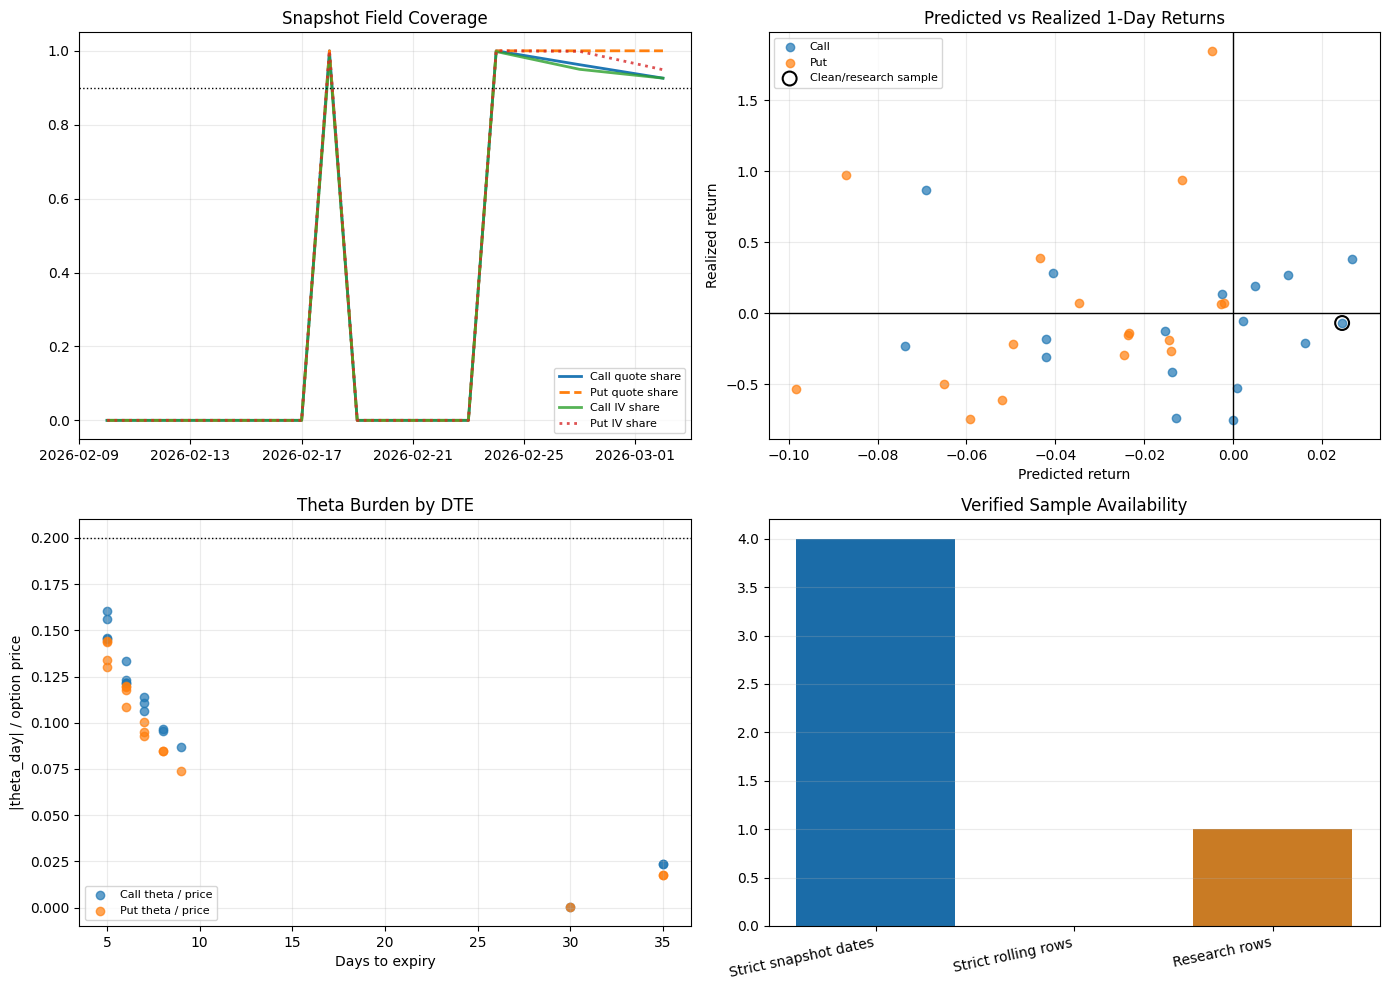

In [11]:
# --- 9) Visual diagnostics ---

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Audit coverage over time
ax = axes[0, 0]
audit_plot = audit_df.copy()
audit_plot["date"] = pd.to_datetime(audit_plot["date"])
ax.plot(audit_plot["date"], audit_plot["call_mid_quote_share"], label="Call quote share", linewidth=2)
ax.plot(audit_plot["date"], audit_plot["put_mid_quote_share"], label="Put quote share", linewidth=2, linestyle="--")
ax.plot(audit_plot["date"], audit_plot["call_iv_positive_share"], label="Call IV share", linewidth=2, alpha=0.8)
ax.plot(audit_plot["date"], audit_plot["put_iv_positive_share"], label="Put IV share", linewidth=2, linestyle=":", alpha=0.8)
ax.axhline(CLEAN_QUOTE_MIN, color="black", linestyle=":", linewidth=1)
ax.set_title("Snapshot Field Coverage")
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=8)
ax.grid(alpha=0.25)

# 2) Predicted vs realized scatter
ax = axes[0, 1]
ax.scatter(df_roll["mu_call_pred_1d"], df_roll["R_call_real_1d"], alpha=0.7, label="Call")
ax.scatter(df_roll["mu_put_pred_1d"], df_roll["R_put_real_1d"], alpha=0.7, label="Put")
if not research_roll.empty:
    ax.scatter(
        research_roll["mu_call_pred_1d"],
        research_roll["R_call_real_1d"],
        s=100,
        facecolors="none",
        edgecolors="black",
        linewidths=1.5,
        label="Clean/research sample",
    )
ax.axhline(0.0, color="black", linewidth=1)
ax.axvline(0.0, color="black", linewidth=1)
ax.set_title("Predicted vs Realized 1-Day Returns")
ax.set_xlabel("Predicted return")
ax.set_ylabel("Realized return")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)

# 3) Theta burden vs DTE
ax = axes[1, 0]
ax.scatter(df_roll["dte"], df_roll["theta_call_ratio"], alpha=0.7, label="Call theta / price")
ax.scatter(df_roll["dte"], df_roll["theta_put_ratio"], alpha=0.7, label="Put theta / price")
ax.axhline(0.20, color="black", linestyle=":", linewidth=1)
ax.set_title("Theta Burden by DTE")
ax.set_xlabel("Days to expiry")
ax.set_ylabel("|theta_day| / option price")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)

# 4) Clean-date counts
ax = axes[1, 1]
summary_labels = ["Strict snapshot dates", "Strict rolling rows", "Research rows"]
summary_vals = [len(strict_snapshot_dates), len(strict_clean_roll), len(research_roll)]
ax.bar(summary_labels, summary_vals, color=["#1b6ca8", "#3a7d44", "#c97b24"])
ax.set_title("Verified Sample Availability")
ax.grid(axis="y", alpha=0.25)
for tick in ax.get_xticklabels():
    tick.set_rotation(12)
    tick.set_ha("right")

plt.tight_layout()
plt.show()


Toy long-only Markowitz allocations on strict snapshot dates:
      date  w_underlying   w_call  w_put   w_cash  mu_underlying   mu_call    mu_put  mu_cash
2026-02-18      0.500508 0.000000    0.0 0.499492       0.000517 -0.000347 -0.015783 0.000198
2026-02-24      0.499733 0.001538    0.0 0.498730       0.000702  0.003129 -0.023243 0.000198


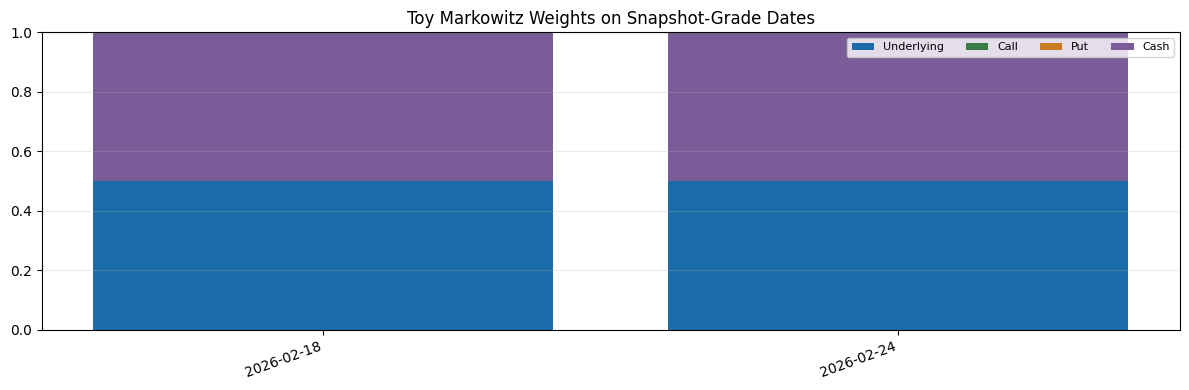

In [12]:
# --- 10) Toy Markowitz optimization on snapshot-grade dates ---

from scipy.optimize import minimize
import matplotlib.pyplot as plt

MARKOWITZ_MAX_DATES = 8
RISK_AVERSION = 4.0

markowitz_dates = strict_snapshot_dates[:MARKOWITZ_MAX_DATES]
markowitz_rows = []


def _solve_long_only_markowitz(mu_vec: np.ndarray, sigma_mat: np.ndarray, risk_aversion: float) -> np.ndarray:
    n = len(mu_vec)
    x0 = np.full(n, 1.0 / n)
    bounds = [(0.0, 1.0)] * n
    constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1.0}]

    def objective(w):
        return -(w @ mu_vec - 0.5 * risk_aversion * (w @ sigma_mat @ w))

    res = minimize(objective, x0=x0, bounds=bounds, constraints=constraints, method="SLSQP")
    if not res.success:
        return x0
    return res.x


if not markowitz_dates:
    print("No strict snapshot-grade dates available for the toy Markowitz test yet.")
else:
    for date_str in markowitz_dates:
        ts = pd.Timestamp(date_str)
        if ts not in spy_df.index:
            continue
        spot = float(spy_df.loc[ts, "close"])
        chain = load_chain_atm(date_str, spot)
        expiry_ts = pd.Timestamp(chain["expiry"])
        T = max((expiry_ts - ts).days / 365.0, 1e-6)
        lookback = spy_df.loc[:ts].tail(63)
        rets = lookback["close"].pct_change().dropna()
        if len(rets) < 10:
            continue
        mu_ann = float(rets.mean() * 252)
        sig_ann = float(rets.std(ddof=1) * np.sqrt(252))
        mu_vec, sigma_mat = build_delta_gamma_moments(
            spot=spot,
            mu=mu_ann,
            sigma=sig_ann,
            r=0.05,
            T=T,
            K_call=chain["K_call"],
            K_put=chain["K_put"],
            C0=chain["C0"],
            P0=chain["P0"],
            dt=1.0 / 252.0,
            sigma_greeks=chain["iv"],
        )
        weights = _solve_long_only_markowitz(mu_vec, sigma_mat, RISK_AVERSION)
        markowitz_rows.append({
            "date": date_str,
            "w_underlying": weights[0],
            "w_call": weights[1],
            "w_put": weights[2],
            "w_cash": weights[3],
            "mu_underlying": mu_vec[0],
            "mu_call": mu_vec[1],
            "mu_put": mu_vec[2],
            "mu_cash": mu_vec[3],
        })

markowitz_df = pd.DataFrame(markowitz_rows)
if markowitz_df.empty:
    print("No clean snapshot-grade dates produced a solvable Markowitz test.")
else:
    print("Toy long-only Markowitz allocations on strict snapshot dates:")
    print(markowitz_df.to_string(index=False))

    fig, ax = plt.subplots(figsize=(12, 4))
    x = np.arange(len(markowitz_df))
    bottom = np.zeros(len(markowitz_df))
    for col, label, color in [
        ("w_underlying", "Underlying", "#1b6ca8"),
        ("w_call", "Call", "#3a7d44"),
        ("w_put", "Put", "#c97b24"),
        ("w_cash", "Cash", "#7a5c99"),
    ]:
        ax.bar(x, markowitz_df[col], bottom=bottom, label=label, color=color)
        bottom += markowitz_df[col].to_numpy()
    ax.set_xticks(x)
    ax.set_xticklabels(markowitz_df["date"], rotation=20, ha="right")
    ax.set_ylim(0.0, 1.0)
    ax.set_title("Toy Markowitz Weights on Snapshot-Grade Dates")
    ax.legend(ncol=4, fontsize=8)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()


---
## 11. Controlled Snapshot Dataset (SPY + Frozen S&P 100 Basket)

The research pipeline now treats Alpaca data in two explicit tiers:

- **Snapshot-grade rows**: live chain snapshots with observable bid/ask, implied volatility, and greeks.
- **Bar-reconstructed rows**: historical option bars without observable IV/greeks; useful for broad coverage, but not for quote-quality inference.

The controlled dataset below is the strict subset we trust for multi-asset research. It is designed to grow over time as daily snapshot captures accumulate for the fixed basket `SPY + frozen S&P 100`.


In [13]:
# --- 11a) Build the controlled snapshot dataset across the fixed universe ---

from data.universes import get_named_universe

SNAPSHOT_PANEL_LOOKBACK = 10
CONTROLLED_QUOTE_MIN = 0.90
CONTROLLED_IV_MIN = 0.90
CONTROLLED_GREEK_MIN = 0.90
RESEARCH_BASKET = get_named_universe("liquid_research_plus_spy")


def _symbol_chain_dir(symbol: str) -> Path:
    return OPTION_CHAINS_DIR if symbol == "SPY" else OPTION_CHAINS_DIR / symbol


def _chain_paths(symbol: str, date_str: str) -> tuple[Path, Path]:
    chain_dir = _symbol_chain_dir(symbol)
    return chain_dir / f"calls_{date_str}.parquet", chain_dir / f"puts_{date_str}.parquet"


def _file_snapshot_fallback(path: Path) -> pd.Timestamp:
    return pd.Timestamp.fromtimestamp(path.stat().st_mtime, tz="UTC").tz_localize(None).floor("s")


def _normalize_snapshot_frame(
    df: pd.DataFrame,
    *,
    fallback_ts: pd.Timestamp,
    snapshot_time: pd.Timestamp | str | None = None,
    latest_only: bool = True,
) -> pd.DataFrame:
    out = df.copy()
    rename_map = {}
    if "impliedVolatility" in out.columns and "impl_vol" not in out.columns:
        rename_map["impliedVolatility"] = "impl_vol"
    if "lastPrice" in out.columns and "lastprice" not in out.columns:
        rename_map["lastPrice"] = "lastprice"
    if rename_map:
        out.rename(columns=rename_map, inplace=True)

    if "snapshot_time" in out.columns:
        snap = pd.to_datetime(out["snapshot_time"], utc=True, errors="coerce")
        out["snapshot_time"] = snap.dt.tz_convert("UTC").dt.tz_localize(None)
        out["snapshot_time"] = out["snapshot_time"].fillna(fallback_ts)
    else:
        out["snapshot_time"] = fallback_ts

    if snapshot_time is not None:
        target = pd.Timestamp(snapshot_time)
        if target.tzinfo is not None:
            target = target.tz_convert("UTC").tz_localize(None)
        out = out[out["snapshot_time"] == target].copy()
    elif latest_only and not out.empty:
        out = out[out["snapshot_time"] == out["snapshot_time"].max()].copy()

    for col in (
        "strike", "bid", "ask", "lastprice", "impl_vol", "delta", "gamma", "theta", "vega", "rho",
        "underlying_bid", "underlying_ask", "underlying_last", "underlying_spot",
    ):
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")
    if "expiry" in out.columns:
        out["expiry"] = pd.to_datetime(out["expiry"]).dt.normalize()

    bid = out.get("bid", pd.Series(np.nan, index=out.index))
    ask = out.get("ask", pd.Series(np.nan, index=out.index))
    last = out.get("lastprice", pd.Series(np.nan, index=out.index))
    has_mid_quote = bid.gt(0) & ask.gt(0) & ask.ge(bid)
    mid = 0.5 * (bid + ask)
    out["has_mid_quote"] = has_mid_quote
    out["mid"] = mid.where(has_mid_quote, last)
    out["mid"] = out["mid"].where(out["mid"] > 0)
    return out


def _load_symbol_chain_day(
    symbol: str,
    date_str: str,
    *,
    snapshot_time: pd.Timestamp | str | None = None,
    latest_only: bool = True,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    calls_path, puts_path = _chain_paths(symbol, date_str)
    calls_raw = pd.read_parquet(calls_path)
    puts_raw = pd.read_parquet(puts_path)
    calls = _normalize_snapshot_frame(
        calls_raw,
        fallback_ts=_file_snapshot_fallback(calls_path),
        snapshot_time=snapshot_time,
        latest_only=latest_only,
    )
    puts = _normalize_snapshot_frame(
        puts_raw,
        fallback_ts=_file_snapshot_fallback(puts_path),
        snapshot_time=snapshot_time,
        latest_only=latest_only,
    )
    return calls, puts


def _available_snapshot_times(symbol: str, date_str: str) -> list[pd.Timestamp]:
    calls, puts = _load_symbol_chain_day(symbol, date_str, latest_only=False)
    if calls.empty or puts.empty or "snapshot_time" not in calls.columns or "snapshot_time" not in puts.columns:
        return []
    shared = sorted(set(calls["snapshot_time"].dropna()) & set(puts["snapshot_time"].dropna()))
    return list(shared)


def _nonnull_share(df: pd.DataFrame, cols: list[str]) -> float:
    if df.empty:
        return np.nan
    present = [c for c in cols if c in df.columns]
    if not present:
        return np.nan
    shares = [float(df[c].notna().mean()) for c in present]
    return float(np.nanmin(shares))


def _positive_share(df: pd.DataFrame, col: str) -> float:
    if df.empty or col not in df.columns:
        return np.nan
    return float(df[col].fillna(0).gt(0).mean())


def _mid_share(df: pd.DataFrame) -> float:
    if df.empty or not {"bid", "ask"}.issubset(df.columns):
        return np.nan
    return float((df["bid"].gt(0) & df["ask"].gt(0) & df["ask"].ge(df["bid"])).mean())


def _snapshot_day_quality(symbol: str, date_str: str) -> dict:
    calls_path, puts_path = _chain_paths(symbol, date_str)
    snapshot_times = _available_snapshot_times(symbol, date_str)
    fallback_ts = max(_file_snapshot_fallback(calls_path), _file_snapshot_fallback(puts_path))
    latest_snapshot_time = snapshot_times[-1] if snapshot_times else fallback_ts
    calls, puts = _load_symbol_chain_day(symbol, date_str, snapshot_time=latest_snapshot_time, latest_only=False)
    ref_ts = pd.Timestamp(date_str)
    common_expiries = sorted(
        set(calls.get("expiry", pd.Series(dtype="datetime64[ns]")).dropna())
        & set(puts.get("expiry", pd.Series(dtype="datetime64[ns]")).dropna())
    )
    future_common = [exp for exp in common_expiries if exp > ref_ts]
    call_greek_share = _nonnull_share(calls, ["delta", "gamma", "theta", "vega", "rho"])
    put_greek_share = _nonnull_share(puts, ["delta", "gamma", "theta", "vega", "rho"])
    snapshot_grade = (
        len(calls) > 0
        and len(puts) > 0
        and len(future_common) > 0
        and (_mid_share(calls) >= CONTROLLED_QUOTE_MIN)
        and (_mid_share(puts) >= CONTROLLED_QUOTE_MIN)
        and (_positive_share(calls, "impl_vol") >= CONTROLLED_IV_MIN)
        and (_positive_share(puts, "impl_vol") >= CONTROLLED_IV_MIN)
        and (call_greek_share >= CONTROLLED_GREEK_MIN)
        and (put_greek_share >= CONTROLLED_GREEK_MIN)
    )
    return {
        "symbol": symbol,
        "date": date_str,
        "latest_snapshot_time": latest_snapshot_time,
        "available_snapshots": len(snapshot_times),
        "calls_rows": len(calls),
        "puts_rows": len(puts),
        "future_common": len(future_common),
        "call_mid_share": _mid_share(calls),
        "put_mid_share": _mid_share(puts),
        "call_iv_share": _positive_share(calls, "impl_vol"),
        "put_iv_share": _positive_share(puts, "impl_vol"),
        "call_greek_share": call_greek_share,
        "put_greek_share": put_greek_share,
        "has_rho_column": int("rho" in calls.columns and "rho" in puts.columns),
        "snapshot_grade": bool(snapshot_grade),
    }


panel_rows = []
available_snapshot_symbols = []
for symbol in RESEARCH_BASKET:
    chain_dir = _symbol_chain_dir(symbol)
    if not chain_dir.exists():
        continue
    files = sorted(chain_dir.glob("calls_*.parquet"))
    if not files:
        continue
    available_snapshot_symbols.append(symbol)
    recent_dates = [p.stem.replace("calls_", "") for p in files[-SNAPSHOT_PANEL_LOOKBACK:]]
    for date_str in recent_dates:
        _, puts_path = _chain_paths(symbol, date_str)
        if not puts_path.exists():
            continue
        try:
            panel_rows.append(_snapshot_day_quality(symbol, date_str))
        except Exception:
            continue

basket_snapshot_panel = pd.DataFrame(panel_rows).sort_values(["date", "symbol"]) if panel_rows else pd.DataFrame()
if not basket_snapshot_panel.empty:
    basket_snapshot_panel["latest_snapshot_time"] = pd.to_datetime(
        basket_snapshot_panel["latest_snapshot_time"], utc=True, errors="coerce"
    ).dt.tz_convert("UTC").dt.tz_localize(None)
controlled_dataset = basket_snapshot_panel[basket_snapshot_panel["snapshot_grade"]].copy() if not basket_snapshot_panel.empty else pd.DataFrame()
latest_snapshot_health = (
    basket_snapshot_panel.sort_values(["symbol", "latest_snapshot_time"]).groupby("symbol", as_index=False).tail(1)
    if not basket_snapshot_panel.empty else pd.DataFrame()
)
analysis_snapshot_panel = controlled_dataset if not controlled_dataset.empty else latest_snapshot_health.copy()

print(f"Available symbols with any archived option data: {len(available_snapshot_symbols)} / {len(RESEARCH_BASKET)}")
if available_snapshot_symbols:
    preview = available_snapshot_symbols[:12]
    suffix = " ..." if len(available_snapshot_symbols) > 12 else ""
    print("Symbols:", ", ".join(preview) + suffix)

if basket_snapshot_panel.empty:
    print("No archived snapshot panel yet for the fixed universe.")
else:
    print("\nControlled snapshot panel (recent rows):")
    print(basket_snapshot_panel.tail(20).to_string(index=False))
    if controlled_dataset.empty:
        print("\nSnapshot-grade coverage by symbol: none yet")
    else:
        print("\nSnapshot-grade coverage by symbol:")
        print(controlled_dataset.groupby("symbol").size().sort_values(ascending=False).to_string())

if latest_snapshot_health.empty:
    print("\nNo latest-snapshot health table yet.")
else:
    most_recent_scrape = latest_snapshot_health["latest_snapshot_time"].max()
    print("\nLatest snapshot date per symbol:")
    print(
        latest_snapshot_health[[
            "symbol", "date", "latest_snapshot_time", "available_snapshots", "snapshot_grade",
            "call_mid_share", "put_mid_share", "call_iv_share", "put_iv_share", "call_greek_share", "put_greek_share",
        ]].sort_values("symbol").to_string(index=False)
    )
    ready = int(latest_snapshot_health["snapshot_grade"].sum())
    total = len(latest_snapshot_health)
    print(
        "\nUniverse health: "
        f"{ready}/{total} symbols have snapshot-grade latest data | "
        f"most recent scrape minute={most_recent_scrape.floor('min').strftime('%Y-%m-%d %H:%M')} | "
        f"median snapshots/day={latest_snapshot_health['available_snapshots'].median():.1f} | "
        f"median call quote share={latest_snapshot_health['call_mid_share'].median():.1%} | "
        f"median call IV share={latest_snapshot_health['call_iv_share'].median():.1%} | "
        f"median call greek share={latest_snapshot_health['call_greek_share'].median():.1%}"
    )




Available symbols with any archived option data: 21 / 21
Symbols: SPY, AAPL, MSFT, NVDA, AMZN, META, TSLA, AMD, GOOGL, JPM, BAC, XOM ...

Controlled snapshot panel (recent rows):
symbol       date latest_snapshot_time  available_snapshots  calls_rows  puts_rows  future_common  call_mid_share  put_mid_share  call_iv_share  put_iv_share  call_greek_share  put_greek_share  has_rho_column  snapshot_grade
   AMD 2026-03-02  2026-03-02 22:01:44                    1          48         48              4        1.000000            1.0       1.000000      1.000000          1.000000         1.000000               1            True
  AMZN 2026-03-02  2026-03-02 22:01:42                    1          92         92              7        1.000000            1.0       1.000000      0.978261          1.000000         0.978261               1            True
  AVGO 2026-03-02  2026-03-02 22:01:47                    1         131        131              7        1.000000            1.0       1.000000   

## 11b. Research-Clean Same-Contract Panel

This section turns the archived full-chain snapshots into a stricter research dataset:

- It screens each chain down to liquid, quoted contracts with positive IV and a complete greek vector.
- It keeps only call/put pairs that share an expiry and can be found again on the next archived date for that symbol.
- It selects a fixed call and put per symbol-date pair so the delta-gamma-theta test compares the same contract at `t` and `t+1`.

Important limitation: the current archive still stores one file per symbol per calendar date. Intraday LaunchAgent runs update that day's file in place, so the notebook can currently test daily or cross-day `delta t`, but not multiple distinct intraday steps until the pipeline writes timestamped snapshot files.



In [14]:
# --- 11c) Build the research-clean same-contract panel for one-period tests ---

from config import RAW_DIR

RESEARCH_MIN_DTE = 7
RESEARCH_MAX_DTE = 35
RESEARCH_TARGET_DTE = 14
RESEARCH_MIN_MID = 0.50
RESEARCH_MAX_REL_SPREAD = 0.10
RESEARCH_MAX_MONEYNESS_GAP = 0.10
RESEARCH_MAX_SYMBOLS = 24
RESEARCH_PANEL_LOOKBACK = 8
RESEARCH_MAX_DT_MINUTES = 60
RESEARCH_MARKET_OPEN_MINUTE = 9 * 60 + 30
RESEARCH_MARKET_CLOSE_MINUTE = 16 * 60
RESEARCH_MARKET_TZ = "America/New_York"


def _market_timestamp(ts: pd.Timestamp | str) -> pd.Timestamp:
    out = pd.Timestamp(ts)
    if out.tzinfo is None:
        out = out.tz_localize("UTC")
    else:
        out = out.tz_convert("UTC")
    return out.tz_convert(RESEARCH_MARKET_TZ)


def _is_regular_market_snapshot(ts: pd.Timestamp | str) -> bool:
    market_ts = _market_timestamp(ts)
    minute_of_day = market_ts.hour * 60 + market_ts.minute
    return market_ts.weekday() < 5 and RESEARCH_MARKET_OPEN_MINUTE <= minute_of_day <= RESEARCH_MARKET_CLOSE_MINUTE


def _load_research_spot(
    symbol: str,
    ts: pd.Timestamp,
    calls_df: pd.DataFrame | None = None,
    puts_df: pd.DataFrame | None = None,
) -> float | None:
    for df in (calls_df, puts_df):
        if df is not None and not df.empty and "underlying_spot" in df.columns:
            vals = pd.to_numeric(df["underlying_spot"], errors="coerce").dropna()
            if not vals.empty:
                return float(vals.iloc[0])
    price_file = SPY_DAILY_FILE if symbol == "SPY" else RAW_DIR / f"{symbol.lower()}_daily.parquet"
    if not price_file.exists():
        return None
    px = pd.read_parquet(price_file)
    if not isinstance(px.index, pd.DatetimeIndex):
        px.index = pd.to_datetime(px.index)
    px.index = px.index.tz_localize(None).normalize()
    px = px.sort_index()
    idx = px.index.get_indexer([pd.Timestamp(ts).normalize()], method="ffill")
    if len(idx) == 0 or idx[0] < 0:
        return None
    return float(px.iloc[idx[0]]["close"])


def _prepare_research_chain(df: pd.DataFrame, side: str, spot: float, ref_ts: pd.Timestamp) -> pd.DataFrame:
    if df.empty or spot is None or not np.isfinite(spot):
        return pd.DataFrame()
    out = df.copy()
    required = ["contractSymbol", "expiry", "strike", "mid", "impl_vol", "delta", "gamma", "theta", "vega", "rho"]
    missing = [c for c in required if c not in out.columns]
    if missing:
        return pd.DataFrame()
    out = out.dropna(subset=required).copy()
    out = out[out["expiry"] > ref_ts.normalize()].copy()
    if out.empty:
        return out
    out["dte"] = (out["expiry"] - ref_ts.normalize()).dt.days
    out = out[(out["dte"] >= RESEARCH_MIN_DTE) & (out["dte"] <= RESEARCH_MAX_DTE)].copy()
    if out.empty:
        return out
    bid = out.get("bid", pd.Series(np.nan, index=out.index))
    ask = out.get("ask", pd.Series(np.nan, index=out.index))
    out["rel_spread"] = (ask - bid) / out["mid"]
    out["moneyness_gap"] = (out["strike"] / spot - 1.0).abs()
    delta_floor = 0.05
    delta_cap = 0.95
    if side == "call":
        out = out[out["delta"].between(delta_floor, delta_cap)]
    else:
        out = out[out["delta"].between(-delta_cap, -delta_floor)]
    out = out[
        out["has_mid_quote"]
        & out["mid"].ge(RESEARCH_MIN_MID)
        & out["impl_vol"].gt(0)
        & out["rel_spread"].between(0, RESEARCH_MAX_REL_SPREAD)
        & out["moneyness_gap"].le(RESEARCH_MAX_MONEYNESS_GAP)
    ].copy()
    if out.empty:
        return out
    out["selection_score"] = out["dte"].sub(RESEARCH_TARGET_DTE).abs() + 25.0 * out["moneyness_gap"] + 10.0 * out["rel_spread"]
    return out.sort_values(["selection_score", "dte", "rel_spread", "moneyness_gap"])


def _recent_snapshot_periods(symbol: str) -> list[dict]:
    symbol_rows = basket_snapshot_panel[basket_snapshot_panel["symbol"] == symbol].sort_values(["date", "latest_snapshot_time"])
    if symbol_rows.empty:
        return []
    events = []
    for _, row in symbol_rows.tail(RESEARCH_PANEL_LOOKBACK).iterrows():
        if not bool(row.get("snapshot_grade", False)):
            continue
        for snap_ts in _available_snapshot_times(symbol, row["date"]):
            snap_ts = pd.Timestamp(snap_ts)
            if not _is_regular_market_snapshot(snap_ts):
                continue
            events.append({"date": row["date"], "snapshot_time": snap_ts})
    if len(events) < 2:
        return []
    events_df = pd.DataFrame(events).drop_duplicates().sort_values(["snapshot_time", "date"])
    records = events_df.to_dict("records")
    periods = []
    for left, right in zip(records[:-1], records[1:]):
        dt_minutes = int((pd.Timestamp(right["snapshot_time"]) - pd.Timestamp(left["snapshot_time"])).total_seconds() // 60)
        if dt_minutes <= 0 or dt_minutes > RESEARCH_MAX_DT_MINUTES:
            continue
        if left["date"] != right["date"]:
            continue
        periods.append({
            "date_t": left["date"],
            "date_t1": right["date"],
            "snapshot_time_t": left["snapshot_time"],
            "snapshot_time_t1": right["snapshot_time"],
            "dt_minutes": dt_minutes,
        })
    return periods


def _research_candidate_for_symbol(symbol: str) -> dict | None:
    periods = _recent_snapshot_periods(symbol)
    if not periods:
        return None

    for period in reversed(periods):
        ts_t = pd.Timestamp(period["snapshot_time_t"])
        ts_t1 = pd.Timestamp(period["snapshot_time_t1"])
        dt_minutes = int(period["dt_minutes"])
        calls_t, puts_t = _load_symbol_chain_day(symbol, period["date_t"], snapshot_time=ts_t, latest_only=False)
        calls_t1, puts_t1 = _load_symbol_chain_day(symbol, period["date_t1"], snapshot_time=ts_t1, latest_only=False)
        if calls_t.empty or puts_t.empty or calls_t1.empty or puts_t1.empty:
            continue

        spot_t = _load_research_spot(symbol, ts_t, calls_t, puts_t)
        spot_t1 = _load_research_spot(symbol, ts_t1, calls_t1, puts_t1)
        if spot_t is None or spot_t1 is None:
            continue

        call_pool = _prepare_research_chain(calls_t, "call", spot_t, ts_t)
        put_pool = _prepare_research_chain(puts_t, "put", spot_t, ts_t)
        if call_pool.empty or put_pool.empty:
            continue

        valid_expiries = sorted(set(call_pool["expiry"]) & set(put_pool["expiry"]))
        if not valid_expiries:
            continue

        call_t1 = calls_t1.set_index("contractSymbol") if "contractSymbol" in calls_t1.columns else pd.DataFrame()
        put_t1 = puts_t1.set_index("contractSymbol") if "contractSymbol" in puts_t1.columns else pd.DataFrame()
        best = None
        best_score = np.inf
        for expiry in valid_expiries:
            calls_exp = call_pool[call_pool["expiry"] == expiry]
            puts_exp = put_pool[put_pool["expiry"] == expiry]
            if calls_exp.empty or puts_exp.empty:
                continue
            for _, call_row in calls_exp.head(8).iterrows():
                call_sym = call_row["contractSymbol"]
                if call_sym not in call_t1.index:
                    continue
                call_next = call_t1.loc[call_sym]
                if isinstance(call_next, pd.DataFrame):
                    call_next = call_next.iloc[0]
                if not bool(call_next.get("has_mid_quote", False)):
                    continue
                if pd.isna(call_next.get("mid", np.nan)) or float(call_next.get("mid", np.nan)) < RESEARCH_MIN_MID:
                    continue
                if pd.isna(call_next.get("impl_vol", np.nan)) or float(call_next.get("impl_vol", np.nan)) <= 0:
                    continue
                if any(pd.isna(call_next.get(g, np.nan)) for g in ["delta", "gamma", "theta", "vega", "rho"]):
                    continue
                for _, put_row in puts_exp.head(8).iterrows():
                    put_sym = put_row["contractSymbol"]
                    if put_sym not in put_t1.index:
                        continue
                    put_next = put_t1.loc[put_sym]
                    if isinstance(put_next, pd.DataFrame):
                        put_next = put_next.iloc[0]
                    if not bool(put_next.get("has_mid_quote", False)):
                        continue
                    if pd.isna(put_next.get("mid", np.nan)) or float(put_next.get("mid", np.nan)) < RESEARCH_MIN_MID:
                        continue
                    if pd.isna(put_next.get("impl_vol", np.nan)) or float(put_next.get("impl_vol", np.nan)) <= 0:
                        continue
                    if any(pd.isna(put_next.get(g, np.nan)) for g in ["delta", "gamma", "theta", "vega", "rho"]):
                        continue
                    score = float(call_row["selection_score"] + put_row["selection_score"])
                    if score >= best_score:
                        continue
                    best_score = score
                    best = {
                        "symbol": symbol,
                        "date_t": period["date_t"],
                        "date_t1": period["date_t1"],
                        "snapshot_time_t": ts_t,
                        "snapshot_time_t1": ts_t1,
                        "dt_minutes": dt_minutes,
                        "spot_t": spot_t,
                        "spot_t1": spot_t1,
                        "expiry": expiry,
                        "call_symbol": call_sym,
                        "put_symbol": put_sym,
                        "call_mid_t": float(call_row["mid"]),
                        "call_mid_t1": float(call_next["mid"]),
                        "put_mid_t": float(put_row["mid"]),
                        "put_mid_t1": float(put_next["mid"]),
                        "call_impl_vol_t": float(call_row["impl_vol"]),
                        "call_impl_vol_t1": float(call_next["impl_vol"]),
                        "put_impl_vol_t": float(put_row["impl_vol"]),
                        "put_impl_vol_t1": float(put_next["impl_vol"]),
                        "call_delta_t": float(call_row["delta"]),
                        "call_gamma_t": float(call_row["gamma"]),
                        "call_theta_t": float(call_row["theta"]),
                        "call_vega_t": float(call_row["vega"]),
                        "call_rho_t": float(call_row["rho"]),
                        "put_delta_t": float(put_row["delta"]),
                        "put_gamma_t": float(put_row["gamma"]),
                        "put_theta_t": float(put_row["theta"]),
                        "put_vega_t": float(put_row["vega"]),
                        "put_rho_t": float(put_row["rho"]),
                        "call_dte_t": int(call_row["dte"]),
                        "put_dte_t": int(put_row["dte"]),
                        "call_rel_spread_t": float(call_row["rel_spread"]),
                        "put_rel_spread_t": float(put_row["rel_spread"]),
                        "call_moneyness_gap": float(call_row["moneyness_gap"]),
                        "put_moneyness_gap": float(put_row["moneyness_gap"]),
                    }
        if best is None:
            continue
        best["R_und_real"] = best["spot_t1"] / best["spot_t"] - 1.0
        best["R_call_real"] = best["call_mid_t1"] / best["call_mid_t"] - 1.0
        best["R_put_real"] = best["put_mid_t1"] / best["put_mid_t"] - 1.0
        best["dIV_call"] = best["call_impl_vol_t1"] - best["call_impl_vol_t"]
        best["dIV_put"] = best["put_impl_vol_t1"] - best["put_impl_vol_t"]
        return best
    return None


research_rows = []
for symbol in RESEARCH_BASKET[:RESEARCH_MAX_SYMBOLS]:
    row = _research_candidate_for_symbol(symbol)
    if row is not None:
        research_rows.append(row)

research_clean_pairs = pd.DataFrame(research_rows).sort_values(["snapshot_time_t1", "symbol"]) if research_rows else pd.DataFrame()

print("Research-clean same-contract panel:")
if research_clean_pairs.empty:
    print("No symbol currently has two snapshot-grade same-day market-hours periods with a tradable same-contract call/put pair.")
else:
    print(research_clean_pairs.to_string(index=False))
    latest_t1 = research_clean_pairs["snapshot_time_t1"].max()
    earliest_t = research_clean_pairs.loc[research_clean_pairs["snapshot_time_t1"] == latest_t1, "snapshot_time_t"].min()
    print(
        "\nResearch panel summary: "
        f"{len(research_clean_pairs)} symbols | "
        f"latest candidate window={earliest_t} -> {latest_t1} | "
        f"max dt={RESEARCH_MAX_DT_MINUTES} minutes | "
        f"median dt={research_clean_pairs['dt_minutes'].median():.1f} minutes | "
        f"median call spread={research_clean_pairs['call_rel_spread_t'].median():.2%} | "
        f"median put spread={research_clean_pairs['put_rel_spread_t'].median():.2%}"
    )



Research-clean same-contract panel:
symbol     date_t    date_t1     snapshot_time_t    snapshot_time_t1  dt_minutes  spot_t  spot_t1     expiry          call_symbol           put_symbol  call_mid_t  call_mid_t1  put_mid_t  put_mid_t1  call_impl_vol_t  call_impl_vol_t1  put_impl_vol_t  put_impl_vol_t1  call_delta_t  call_gamma_t  call_theta_t  call_vega_t  call_rho_t  put_delta_t  put_gamma_t  put_theta_t  put_vega_t  put_rho_t  call_dte_t  put_dte_t  call_rel_spread_t  put_rel_spread_t  call_moneyness_gap  put_moneyness_gap  R_und_real  R_call_real  R_put_real  dIV_call  dIV_put
  AAPL 2026-02-27 2026-02-27 2026-02-27 20:00:55 2026-02-27 20:59:58          59  272.95  264.000 2026-03-27  AAPL260327C00275000  AAPL260327P00270000       3.760       3.4450      9.590      10.615           0.2470            0.2517          0.2536           0.2612        0.3276        0.0199       -0.1254       0.2654      0.0638      -0.5682       0.0211      -0.1148      0.2889    -0.1230          28      

In [15]:
# --- 11d) One-period ex post delta-gamma-theta-vega check on the research-clean panel ---

RESEARCH_THETA_IS_PER_YEAR = globals().get("THETA_INPUT_IS_PER_YEAR", True)

if research_clean_pairs.empty:
    print("No research-clean same-contract rows are available for a one-period approximation test yet.")
else:
    dominant_window = (
        research_clean_pairs.groupby(["snapshot_time_t", "snapshot_time_t1"]).size().sort_values(ascending=False).reset_index(name="count").iloc[0]
    )
    window_t = dominant_window["snapshot_time_t"]
    window_t1 = dominant_window["snapshot_time_t1"]
    research_window = research_clean_pairs[
        (research_clean_pairs["snapshot_time_t"] == window_t) & (research_clean_pairs["snapshot_time_t1"] == window_t1)
    ].copy()

    research_window["dS"] = research_window["spot_t1"] - research_window["spot_t"]
    research_window["dt_trading_days"] = research_window["dt_minutes"].clip(lower=1) / 390.0
    research_window["call_theta_day"] = research_window["call_theta_t"].apply(lambda x: normalize_theta(x, theta_is_per_year=RESEARCH_THETA_IS_PER_YEAR))
    research_window["put_theta_day"] = research_window["put_theta_t"].apply(lambda x: normalize_theta(x, theta_is_per_year=RESEARCH_THETA_IS_PER_YEAR))

    research_window["call_dprice_explained"] = (
        research_window["call_delta_t"] * research_window["dS"]
        + 0.5 * research_window["call_gamma_t"] * research_window["dS"].pow(2)
        + research_window["call_theta_day"] * research_window["dt_trading_days"]
        + research_window["call_vega_t"] * research_window["dIV_call"]
    )
    research_window["put_dprice_explained"] = (
        research_window["put_delta_t"] * research_window["dS"]
        + 0.5 * research_window["put_gamma_t"] * research_window["dS"].pow(2)
        + research_window["put_theta_day"] * research_window["dt_trading_days"]
        + research_window["put_vega_t"] * research_window["dIV_put"]
    )

    research_window["R_call_explained"] = research_window["call_dprice_explained"] / research_window["call_mid_t"]
    research_window["R_put_explained"] = research_window["put_dprice_explained"] / research_window["put_mid_t"]
    research_window["call_abs_err"] = (research_window["R_call_explained"] - research_window["R_call_real"]).abs()
    research_window["put_abs_err"] = (research_window["R_put_explained"] - research_window["R_put_real"]).abs()

    cols = [
        "symbol", "snapshot_time_t", "snapshot_time_t1", "dt_minutes", "call_symbol", "put_symbol",
        "R_und_real", "R_call_explained", "R_call_real", "R_put_explained", "R_put_real",
        "call_abs_err", "put_abs_err", "dIV_call", "dIV_put",
    ]
    print(f"Dominant same-day market-hours test window: {window_t} -> {window_t1} | symbols={len(research_window)}")
    print("Ex post decomposition only: realized dS and realized dIV are used, so this is not an ex ante forecast.")
    print(research_window[cols].to_string(index=False))

    underlying_summary = pd.DataFrame({
        "metric": ["underlying_realized_mean", "underlying_realized_std"],
        "value": [research_window["R_und_real"].mean(), research_window["R_und_real"].std(ddof=1) if len(research_window) >= 2 else np.nan],
    })
    print("\nUnderlying move context (realized only):")
    print(underlying_summary.to_string(index=False))

    option_explained = research_window[["R_call_explained", "R_put_explained"]].to_numpy()
    option_real = research_window[["R_call_real", "R_put_real"]].to_numpy()
    mean_compare = pd.DataFrame({
        "asset": ["call", "put"],
        "mean_explained": option_explained.mean(axis=0),
        "mean_real": option_real.mean(axis=0),
        "abs_error": np.abs(option_explained.mean(axis=0) - option_real.mean(axis=0)),
    })
    print("\nCross-sectional option means (ex post explained vs realized):")
    print(mean_compare.to_string(index=False))

    if len(research_window) >= 2:
        cov_explained = np.cov(option_explained.T, ddof=1)
        cov_real = np.cov(option_real.T, ddof=1)
        cov_diff = cov_explained - cov_real
        labels = ["call", "put"]
        print("\nExplained option covariance across symbols:")
        print(pd.DataFrame(cov_explained, index=labels, columns=labels).to_string())
        print("\nRealized option covariance across symbols:")
        print(pd.DataFrame(cov_real, index=labels, columns=labels).to_string())
        print("\nOption covariance gap (explained - real):")
        print(pd.DataFrame(cov_diff, index=labels, columns=labels).to_string())
    else:
        print("\nNeed at least two symbols in the same window to estimate cross-sectional option covariance.")



Dominant same-day market-hours test window: 2026-02-27 20:00:55 -> 2026-02-27 20:59:58 | symbols=1
Ex post decomposition only: realized dS and realized dIV are used, so this is not an ex ante forecast.
symbol     snapshot_time_t    snapshot_time_t1  dt_minutes         call_symbol          put_symbol  R_und_real  R_call_explained  R_call_real  R_put_explained  R_put_real  call_abs_err  put_abs_err  dIV_call  dIV_put
  AAPL 2026-02-27 20:00:55 2026-02-27 20:59:58          59 AAPL260327C00275000 AAPL260327P00270000    -0.03279         -0.567507    -0.083777         0.618623    0.106882      0.483731     0.511741    0.0047   0.0076

Underlying move context (realized only):
                  metric    value
underlying_realized_mean -0.03279
 underlying_realized_std      NaN

Cross-sectional option means (ex post explained vs realized):
asset  mean_explained  mean_real  abs_error
 call       -0.567507  -0.083777   0.483731
  put        0.618623   0.106882   0.511741

Need at least two symbol

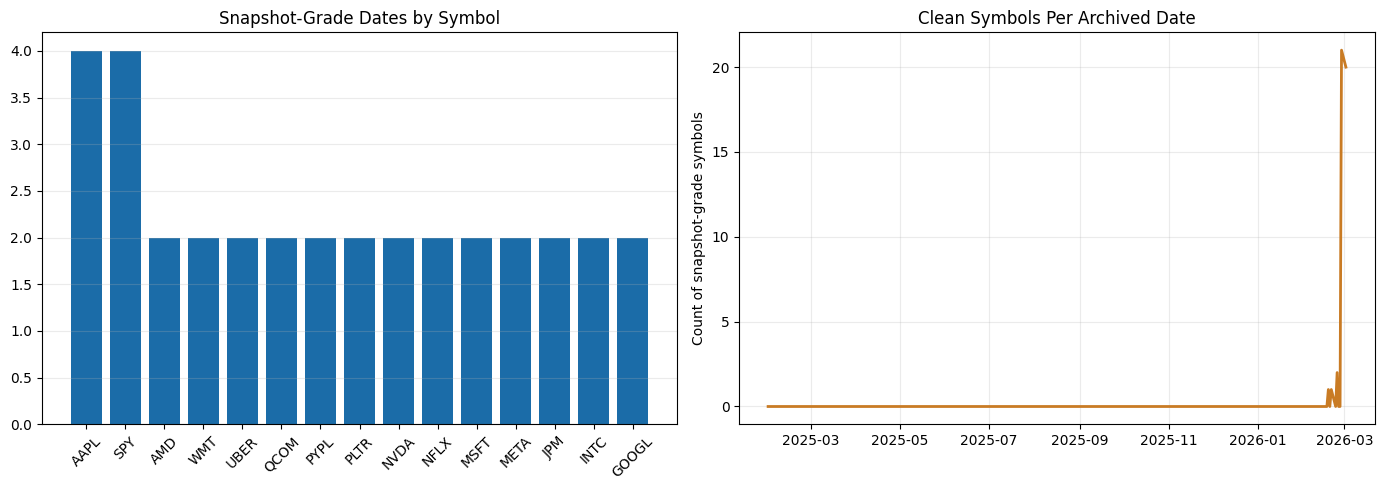

In [16]:
# --- 11e) Controlled dataset visualization ---

import matplotlib.pyplot as plt

if basket_snapshot_panel.empty:
    print("No controlled snapshot panel to visualize yet.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    clean_counts = controlled_dataset.groupby("symbol").size().sort_values(ascending=False)
    top_counts = clean_counts.head(15) if not clean_counts.empty else pd.Series(dtype=float)
    if top_counts.empty:
        axes[0].text(0.5, 0.5, "No snapshot-grade rows yet", ha="center", va="center")
        axes[0].set_axis_off()
    else:
        axes[0].bar(top_counts.index, top_counts.values, color="#1b6ca8")
        axes[0].set_title("Snapshot-Grade Dates by Symbol")
        axes[0].tick_params(axis="x", rotation=45)
        axes[0].grid(axis="y", alpha=0.25)

    date_counts = basket_snapshot_panel.groupby("date")["snapshot_grade"].sum().sort_index()
    axes[1].plot(pd.to_datetime(date_counts.index), date_counts.values, linewidth=2, color="#c97b24")
    axes[1].set_title("Clean Symbols Per Archived Date")
    axes[1].set_ylabel("Count of snapshot-grade symbols")
    axes[1].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()



Candidate contracts on the latest archived snapshot:
    contractSymbol     expiry  strike  dte    mid
SPY260316C00620000 2026-03-16   620.0   14 68.515
SPY260316C00625000 2026-03-16   625.0   14 62.735
SPY260316C00630000 2026-03-16   630.0   14 57.970
SPY260316C00635000 2026-03-16   635.0   14 52.950
SPY260316C00640000 2026-03-16   640.0   14 48.305
SPY260316C00645000 2026-03-16   645.0   14 44.330
SPY260316C00650000 2026-03-16   650.0   14 38.995
SPY260316C00655000 2026-03-16   655.0   14 34.590
SPY260316C00660000 2026-03-16   660.0   14 30.695
SPY260316C00665000 2026-03-16   665.0   14 26.000
Selected contract: SPY260316C00620000
      snapshot_time       date    mid  lastprice  impl_vol  delta  gamma   theta   vega   rho
2026-03-02 22:01:41 2026-03-02 68.515        0.0    0.3671 0.9283 0.0028 -0.2978 0.1838 0.218


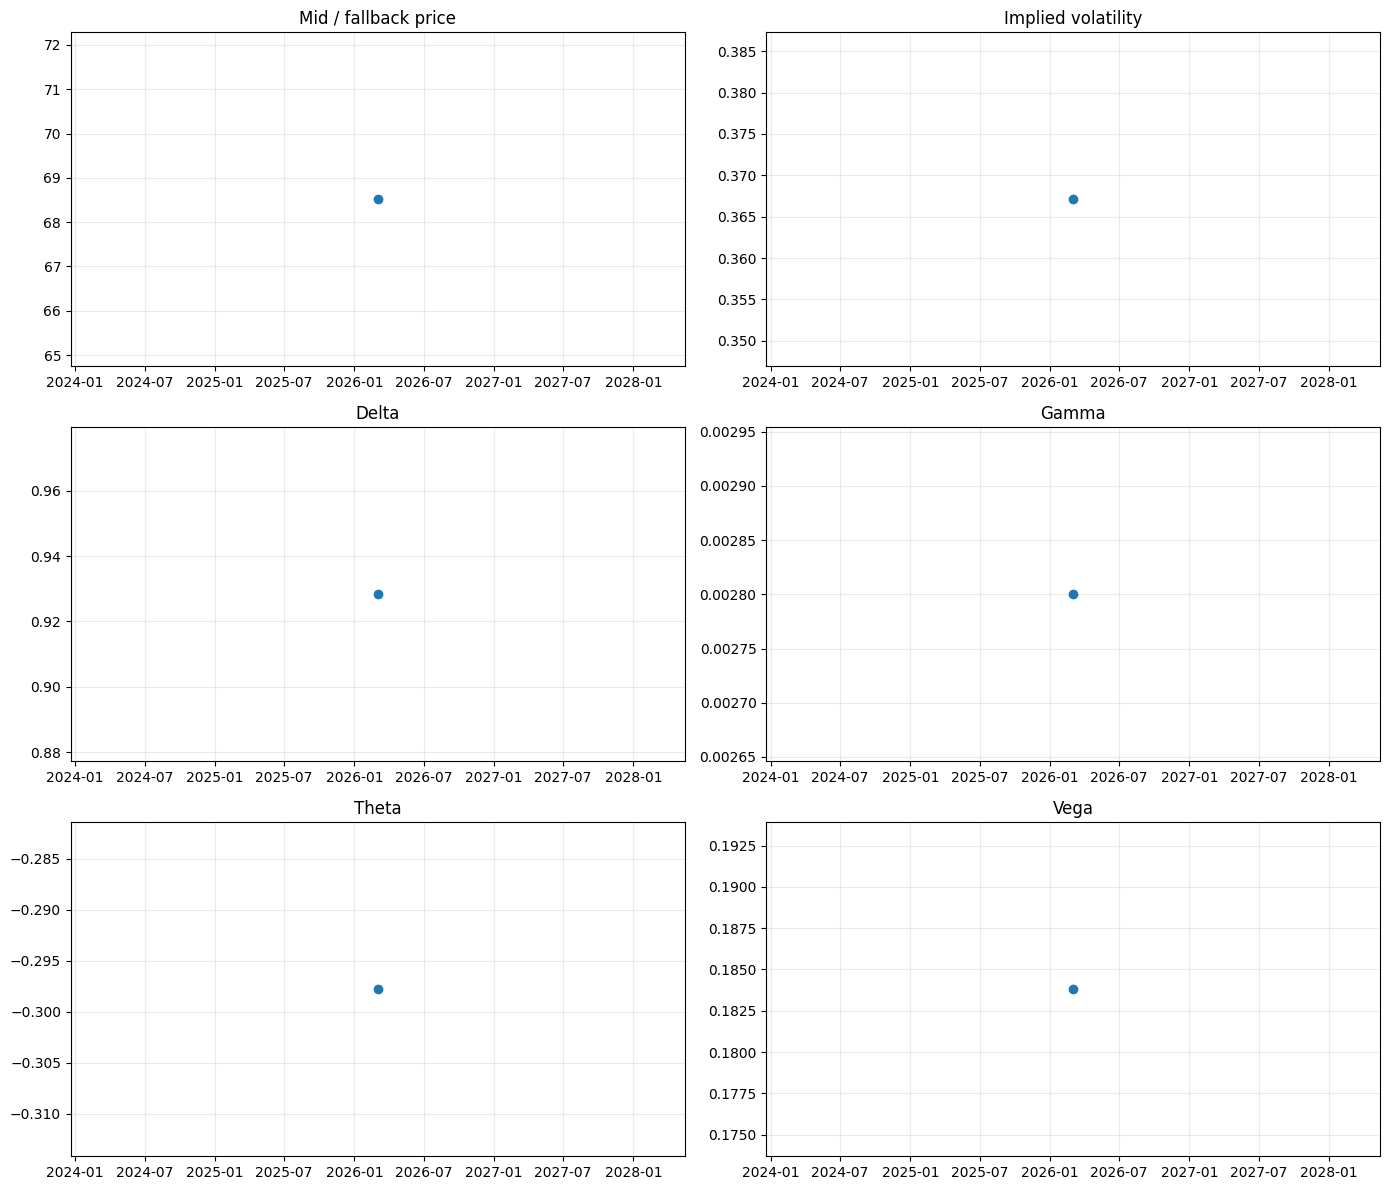

In [17]:
# --- 12) Greeks through time for a chosen contract ---

import matplotlib.pyplot as plt

TRACK_UNDERLYING = "SPY"
TRACK_IS_CALL = True
TRACK_CONTRACT_SYMBOL = None
TRACK_EXPIRY = None          # e.g. "2026-03-20"
TRACK_STRIKE = None          # e.g. 690.0
TRACK_DTE_TARGET = 14
TRACK_HISTORY_DAYS = 30


def _choose_reference_contract(symbol: str) -> tuple[str | None, pd.DataFrame]:
    symbol_rows = basket_snapshot_panel[basket_snapshot_panel["symbol"] == symbol].copy()
    if symbol_rows.empty:
        return None, pd.DataFrame()
    latest_row = symbol_rows.sort_values(["date", "latest_snapshot_time"]).iloc[-1]
    calls, puts = _load_symbol_chain_day(symbol, latest_row["date"], snapshot_time=latest_row["latest_snapshot_time"], latest_only=False)
    chain = calls if TRACK_IS_CALL else puts
    if chain.empty:
        return None, pd.DataFrame()
    ref_ts = pd.Timestamp(latest_row["date"])
    chain = chain[chain["expiry"] > ref_ts].copy()
    if chain.empty:
        return None, pd.DataFrame()
    if TRACK_EXPIRY is not None:
        chain = chain[chain["expiry"] == pd.Timestamp(TRACK_EXPIRY)]
    chain["dte"] = (chain["expiry"] - ref_ts).dt.days
    if TRACK_STRIKE is not None:
        chain["strike_distance"] = (chain["strike"] - float(TRACK_STRIKE)).abs()
    else:
        chain["strike_distance"] = 0.0
    chain["dte_distance"] = (chain["dte"] - TRACK_DTE_TARGET).abs()
    chain = chain.sort_values(["dte_distance", "strike_distance", "has_mid_quote"], ascending=[True, True, False])
    return (chain.iloc[0]["contractSymbol"] if not chain.empty else None), chain[["contractSymbol", "expiry", "strike", "dte", "mid"]].head(10)


selected_contract = TRACK_CONTRACT_SYMBOL
candidate_preview = pd.DataFrame()
if selected_contract is None:
    selected_contract, candidate_preview = _choose_reference_contract(TRACK_UNDERLYING)

if selected_contract is None:
    print("No contract available for the requested underlying/filters.")
else:
    if not candidate_preview.empty:
        print("Candidate contracts on the latest archived snapshot:")
        print(candidate_preview.to_string(index=False))
    print(f"Selected contract: {selected_contract}")

    chain_dir = _symbol_chain_dir(TRACK_UNDERLYING)
    call_files = sorted(chain_dir.glob("calls_*.parquet"))[-TRACK_HISTORY_DAYS:]
    rows = []
    for p in call_files:
        date_str = p.stem.replace("calls_", "")
        for snap_ts in _available_snapshot_times(TRACK_UNDERLYING, date_str):
            calls, puts = _load_symbol_chain_day(TRACK_UNDERLYING, date_str, snapshot_time=snap_ts, latest_only=False)
            chain = calls if TRACK_IS_CALL else puts
            row = chain[chain["contractSymbol"] == selected_contract]
            if row.empty:
                continue
            row = row.iloc[0]
            rows.append({
                "snapshot_time": pd.Timestamp(snap_ts),
                "date": pd.Timestamp(date_str),
                "mid": row.get("mid", np.nan),
                "lastprice": row.get("lastprice", np.nan),
                "impl_vol": row.get("impl_vol", np.nan),
                "delta": row.get("delta", np.nan),
                "gamma": row.get("gamma", np.nan),
                "theta": row.get("theta", np.nan),
                "vega": row.get("vega", np.nan),
                "rho": row.get("rho", np.nan),
            })

    contract_greek_history = pd.DataFrame(rows).sort_values("snapshot_time") if rows else pd.DataFrame()
    if contract_greek_history.empty:
        print("The selected contract is not present across archived snapshots yet.")
    else:
        print(contract_greek_history.to_string(index=False))
        fig, axes = plt.subplots(3, 2, figsize=(14, 12))
        cols = [
            ("mid", "Mid / fallback price"),
            ("impl_vol", "Implied volatility"),
            ("delta", "Delta"),
            ("gamma", "Gamma"),
            ("theta", "Theta"),
            ("vega", "Vega"),
        ]
        x = contract_greek_history["snapshot_time"]
        for ax, (col, title) in zip(axes.flat, cols):
            ax.plot(x, contract_greek_history[col], marker="o", linewidth=2)
            ax.set_title(title)
            ax.grid(alpha=0.25)
        plt.tight_layout()
        plt.show()



In [18]:
# --- 13) Basket-level Markowitz mock-up on the controlled dataset ---

from scipy.optimize import minimize
import matplotlib.pyplot as plt
from config import RAW_DIR

BASKET_LOOKBACK_DAYS = 63
BASKET_RISK_AVERSION = 5.0
BASKET_MAX_SYMBOLS = 12


def _load_stock_history(symbol: str) -> pd.DataFrame:
    price_file = SPY_DAILY_FILE if symbol == "SPY" else RAW_DIR / f"{symbol.lower()}_daily.parquet"
    if not price_file.exists():
        return pd.DataFrame()
    df = pd.read_parquet(price_file)
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)
    df.index = df.index.tz_localize(None).normalize()
    return df.sort_index()


def _solve_long_only(mu_vec: np.ndarray, sigma_mat: np.ndarray, risk_aversion: float) -> np.ndarray:
    n = len(mu_vec)
    x0 = np.full(n, 1.0 / n)
    bounds = [(0.0, 1.0)] * n
    constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1.0}]

    def objective(w):
        return -(w @ mu_vec - 0.5 * risk_aversion * (w @ sigma_mat @ w))

    res = minimize(objective, x0=x0, bounds=bounds, constraints=constraints, method="SLSQP")
    return res.x if res.success else x0


if analysis_snapshot_panel.empty:
    print("No snapshot-grade multi-asset dataset yet; the basket Markowitz mock-up will become active after more daily snapshot captures.")
else:
    latest_clean_date = analysis_snapshot_panel["date"].max()
    candidate_symbols = analysis_snapshot_panel.loc[analysis_snapshot_panel["date"] == latest_clean_date, "symbol"].tolist()
    candidate_symbols = candidate_symbols[:BASKET_MAX_SYMBOLS]

    stock_returns = {}
    symbol_specs = []
    for symbol in candidate_symbols:
        px = _load_stock_history(symbol)
        if px.empty or pd.Timestamp(latest_clean_date) not in px.index:
            continue
        rets = px["close"].pct_change().dropna()
        trailing = rets.loc[:pd.Timestamp(latest_clean_date)].tail(BASKET_LOOKBACK_DAYS)
        if len(trailing) < 20:
            continue
        stock_returns[symbol] = trailing
        spot = float(px.loc[pd.Timestamp(latest_clean_date), "close"])
        try:
            chain = load_chain_atm(latest_clean_date, spot, underlying=symbol)
        except Exception:
            continue
        expiry_ts = pd.Timestamp(chain["expiry"])
        T = max((expiry_ts - pd.Timestamp(latest_clean_date)).days / 365.0, 1e-6)
        mu_ann = float(trailing.mean() * 252)
        sig_ann = float(trailing.std(ddof=1) * np.sqrt(252))
        mu_vec, _ = build_delta_gamma_moments(
            spot=spot,
            mu=mu_ann,
            sigma=sig_ann,
            r=0.05,
            T=T,
            K_call=chain["K_call"],
            K_put=chain["K_put"],
            C0=chain["C0"],
            P0=chain["P0"],
            dt=1.0 / 252.0,
            sigma_greeks=chain["iv"],
        )
        delta_c = _bs_delta(spot, chain["K_call"], 0.05, T, chain["iv"], is_call=True)
        delta_p = _bs_delta(spot, chain["K_put"], 0.05, T, chain["iv"], is_call=False)
        symbol_specs.append({
            "symbol": symbol,
            "mu_vec": mu_vec[:3],
            "call_exposure": delta_gamma_exposure(delta_c, spot, chain["C0"]),
            "put_exposure": delta_gamma_exposure(delta_p, spot, chain["P0"]),
        })

    if not symbol_specs:
        print("No symbols had enough clean data and stock history for the basket Markowitz mock-up.")
    else:
        aligned = pd.concat({sym: stock_returns[sym] for sym in [spec["symbol"] for spec in symbol_specs]}, axis=1).dropna()
        if aligned.empty:
            print("Stock return histories did not overlap enough for a basket covariance estimate.")
        else:
            stock_cov = aligned.cov().to_numpy()
            n_sym = len(symbol_specs)
            labels = []
            mu_assets = []
            exposure = np.zeros((3 * n_sym + 1, n_sym))
            for i, spec in enumerate(symbol_specs):
                sym = spec["symbol"]
                labels.extend([f"{sym}_stock", f"{sym}_call", f"{sym}_put"])
                mu_assets.extend(spec["mu_vec"].tolist())
                exposure[3 * i, i] = 1.0
                exposure[3 * i + 1, i] = spec["call_exposure"]
                exposure[3 * i + 2, i] = spec["put_exposure"]
            labels.append("cash")
            mu_assets.append(np.exp(0.05 / 252.0) - 1.0)
            sigma_assets = exposure @ stock_cov @ exposure.T
            sigma_assets[-1, :] = 0.0
            sigma_assets[:, -1] = 0.0
            sigma_assets[-1, -1] = 1e-10
            sigma_assets += np.eye(len(labels)) * 1e-10

            weights = _solve_long_only(np.array(mu_assets), sigma_assets, BASKET_RISK_AVERSION)
            basket_markowitz_df = pd.DataFrame({"asset": labels, "weight": weights, "mu_pred": mu_assets})
            basket_markowitz_df = basket_markowitz_df.sort_values("weight", ascending=False)

            print(f"Latest clean basket date: {latest_clean_date}")
            print(basket_markowitz_df.to_string(index=False))

            fig, ax = plt.subplots(figsize=(12, 4))
            top = basket_markowitz_df.head(15)
            ax.bar(top["asset"], top["weight"], color="#3a7d44")
            ax.set_title("Basket Markowitz Weights on Clean Snapshot Dataset")
            ax.tick_params(axis="x", rotation=45)
            ax.grid(axis="y", alpha=0.25)
            plt.tight_layout()
            plt.show()


No symbols had enough clean data and stock history for the basket Markowitz mock-up.
